In [33]:
import sys
import platform
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import torchvision
import torchvision.models as models
from torchvision import transforms
from PIL import Image
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                              confusion_matrix, precision_score, recall_score,
                              balanced_accuracy_score, roc_curve)
from sklearn.decomposition import PCA
from sklearn.metrics import cohen_kappa_score, brier_score_loss
import torch.nn as nn
import torch.optim as optim
import cv2
from tqdm import tqdm
import warnings
import gc
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path as _Path

FIGURES_DIR = _Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


ENV_INFO = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
    "opencv": cv2.__version__,
    "sklearn": __import__("sklearn").__version__,
}
print("\nEnvironment (record this verbatim in the manuscript's Implementation section):")
for k, v in ENV_INFO.items():
    print(f"  {k}: {v}")


IMAGE_FOLDER  = r"D:\New folder (2)\A3 Radiogenomics Cancer Detection\jpg_img"
CALC_CSV      = r"calc_case(with_jpg_img).csv"
MASS_CSV      = r"mass_case(with_jpg_img).csv"
METADATA_CSV  = r"metadata(with_jpg_img).csv"

IMAGE_TYPE = 'ROI mask images'
MAX_IMAGES_PER_PATIENT = 5
TEST_SIZE = 0.2
BALANCE_DATA = True


N_SEEDS = 10
RANDOM_SEEDS = [42, 123, 456, 789, 2024, 7, 99, 555, 1001, 31415]

RESIZE_SIZE = (224, 224)
RESIZE_INTERPOLATION = cv2.INTER_LINEAR      
RESIZE_INTERPOLATION_NAME = "bilinear (cv2.INTER_LINEAR)"
INTENSITY_SCALE = "divide by 255.0 -> [0,1] float32"
NORMALIZE_MEAN = [0.485, 0.456, 0.406]        
NORMALIZE_STD  = [0.229, 0.224, 0.225]        

print("\nPreprocessing configuration (record in manuscript Methods):")
print(f"  Resize: {RESIZE_SIZE}, interpolation = {RESIZE_INTERPOLATION_NAME}")
print(f"  Intensity scaling: {INTENSITY_SCALE}")
print(f"  Channel normalization (mean/std): {NORMALIZE_MEAN} / {NORMALIZE_STD}")
print(f"  Grayscale -> 3-channel replication before normalization")


MODEL_NAMES = ['resnet18', 'resnet50', 'mobilenet_v2', 'densenet121', 'vit_b_16']


MIAS_DIR = r"D:\New folder (2)\A3 Radiogenomics Cancer Detection\all-mias"
MIAS_INFO_PATH = r"D:\New folder (2)\A3 Radiogenomics Cancer Detection\all-mias\Info.txt"


Using device: cpu

Environment (record this verbatim in the manuscript's Implementation section):
  python: 3.14.4
  platform: Windows-10-10.0.19045-SP0
  numpy: 2.4.6
  pandas: 3.0.3
  torch: 2.12.0+cpu
  torchvision: 0.27.0+cpu
  opencv: 5.0.0
  sklearn: 1.8.0

Preprocessing configuration (record in manuscript Methods):
  Resize: (224, 224), interpolation = bilinear (cv2.INTER_LINEAR)
  Intensity scaling: divide by 255.0 -> [0,1] float32
  Channel normalization (mean/std): [0.485, 0.456, 0.406] / [0.229, 0.224, 0.225]
  Grayscale -> 3-channel replication before normalization


## STEP 1 — Dataset construction (addresses Reviewer 2's request to clarify
selection / exclusion procedure)

The raw metadata contains 6,775 imaging-study folders across 1,566 unique
patients (Calc: 1,872 records, Mass: 1,696 records — these overlap with
metadata rows because one folder can contain multiple DICOM series).
The manuscript should state explicitly, as documented by the code below:

- **Inclusion**: any folder listed in `metadata.csv` that merges successfully
  (inner join) with a calc/mass pathology record.
- **Exclusion**: folders with no matching pathology record are dropped
  (`dropna(subset=['label'])`); rows are further filtered to
  `series_description == 'ROI mask images'` in Step 4 (ROI masks were chosen
  over full mammograms/cropped images because the ROI already isolates the
  lesion — this choice should be justified or an ablation with full
  mammograms added; see the "Limitations" note in STEP 2).
- **Patient-level label**: a patient is labelled MALIGNANT if *any* of their
  studies is malignant (`.agg(label=('label','max'))`), otherwise BENIGN.
- **Multiple images per patient**: capped at `MAX_IMAGES_PER_PATIENT = 5`
  (Step 4) to prevent a small number of patients with many images from
  dominating the training set.

In [2]:
def build_master_folder_list(metadata_csv, calc_csv, mass_csv):
    print("=" * 65)
    print("STEP 1: BUILDING MASTER LABELED FOLDER LIST")
    print("=" * 65)

    meta = pd.read_csv(metadata_csv)
    meta['folder_name'] = (meta['jpg_folder_path']
                            .str.replace('jpg_img/', '', regex=False)
                            .str.strip())
    meta['patient_id'] = meta['Subject ID'].str.extract(r'(P_\d+)')[0]

    print(f"Metadata folders: {len(meta)}")
    print(f"Unique patients: {meta['patient_id'].nunique()}")

    calc = pd.read_csv(calc_csv)
    mass = pd.read_csv(mass_csv)

    if 'breast density' in calc.columns:
        calc = calc.rename(columns={'breast density': 'breast_density'})
    calc['cancer_type'] = 'Calcification'
    mass['cancer_type'] = 'Mass'

    cases = pd.concat([calc, mass], ignore_index=True)
    cases['label'] = (cases['pathology'] == 'MALIGNANT').astype(int)

    print(f"Calc records: {len(calc)}, Mass records: {len(mass)}")
    print(f"\nPathology:\n{cases['pathology'].value_counts()}")

    patient_labels = (cases.groupby('patient_id')
                       .agg(label=('label', 'max'),
                            pathology=('pathology', lambda x: 'MALIGNANT' if (x == 'MALIGNANT').any() else x.iloc[0]),
                            cancer_type=('cancer_type', 'first'))
                       .reset_index())

    print(f"\nPatients: {len(patient_labels)} (Benign={sum(patient_labels['label']==0)}, Malignant={sum(patient_labels['label']==1)})")

    n_before = len(meta)
    master = meta.merge(patient_labels, on='patient_id', how='inner')
    n_after_merge = len(master)
    master = master.dropna(subset=['label'])
    n_after_dropna = len(master)
    master['label'] = master['label'].astype(int)
    master = master.rename(columns={'Series Description': 'series_description', 'Number of Images': 'num_images'})

    # --- Explicit exclusion log for the manuscript (Reviewer 2) ---
    print("\nDataset construction log:")
    print(f"  Metadata rows (start):                {n_before}")
    print(f"  After inner-join with pathology table: {n_after_merge}  "
          f"({n_before - n_after_merge} dropped: no pathology match)")
    print(f"  After dropping missing labels:         {n_after_dropna}  "
          f"({n_after_merge - n_after_dropna} dropped: missing label)")

    print(f"\nMaster records: {len(master)}")
    print(f"Series Description:\n{master['series_description'].value_counts()}")
    print(f"Label distribution: {master['label'].value_counts().to_dict()}")

    return master

In [3]:
def generate_synthetic_genetic_data(master_df, seed=42):
    """
    Synthetic genetic-marker generator.

    For each patient, each marker is drawn independently from a Bernoulli
    distribution whose success probability depends ONLY on the patient's
    pathology label:

        P(marker=1 | malignant)  = p_mal[marker]
        P(marker=1 | benign)     = p_ben[marker]

    i.e. marker ~ Bernoulli(p_mal) if malignant else Bernoulli(p_ben)

    This is a deliberate design choice to create a *label-correlated proxy*,
    NOT a biologically grounded simulation of real mutation prevalence.
    The probabilities below are documented explicitly so the exact
    generative process is auditable and reproducible.
    """
    rng = np.random.default_rng(seed)

    p_mal = {'BRCA1_mutation': 0.30, 'BRCA2_mutation': 0.20,
              'TP53_mutation': 0.40, 'HER2_amplification': 0.25,
              'ER_status': 0.40, 'PR_status': 0.45}
    p_ben = {'BRCA1_mutation': 0.02, 'BRCA2_mutation': 0.03,
              'TP53_mutation': 0.05, 'HER2_amplification': 0.03,
              'ER_status': 0.15, 'PR_status': 0.20}

    print("\n" + "=" * 65)
    print("STEP 2: GENERATING SYNTHETIC GENETIC LABELS (proxy, not real biology)")
    print("=" * 65)
    print("Generative formula: marker ~ Bernoulli(p_mal) if malignant else Bernoulli(p_ben)")
    print(f"seed = {seed}")
    print(f"{'marker':22s} {'P(1|malignant)':>15s} {'P(1|benign)':>13s} {'design corr. w/ label':>22s}")

    patients = master_df[['patient_id', 'label']].drop_duplicates('patient_id')
    genetic_data = []

    for _, row in patients.iterrows():
        patient_id = row['patient_id']
        is_malignant = (row['label'] == 1)
        profile = {'patient_id': patient_id, 'label': int(row['label'])}
        for marker in p_mal:
            prob = p_mal[marker] if is_malignant else p_ben[marker]
            profile[marker] = int(rng.random() < prob)
        profile['grade'] = rng.choice([1, 2, 3], p=[0.1, 0.3, 0.6] if is_malignant else [0.7, 0.25, 0.05])
        profile['ki67_score'] = rng.uniform(20, 80) if is_malignant else rng.uniform(5, 25)
        profile['molecular_subtype'] = (rng.choice(['Luminal A', 'Luminal B', 'HER2-enriched', 'Triple Negative'],
                                                     p=[0.3, 0.25, 0.25, 0.2]) if is_malignant else 'Benign')
        genetic_data.append(profile)

    genetic_df = pd.DataFrame(genetic_data)

    # --- Design-correlation report: proves, numerically, that these labels
    #     are constructed from pathology, not independent biology ---------
    for marker in p_mal:
        corr = np.corrcoef(genetic_df['label'], genetic_df[marker])[0, 1]
        print(f"{marker:22s} {p_mal[marker]:15.2f} {p_ben[marker]:13.2f} {corr:22.3f}")

    print(f"\n(Correlations above are BY CONSTRUCTION — this is the number that "
          f"should be quoted whenever a radiogenomics AUC for these markers is "
          f"reported, so readers can judge how much of any downstream AUC is "
          f"attributable to the label's dependence on pathology rather than to "
          f"genuine imaging-genomic structure.)")

    print(
        "\nIndependence from image characteristics (Reviewer 2's explicit "
        "question): each marker is sampled using ONLY (a) the patient's "
        "pathology label and (b) the RNG seed above -- no pixel data, no CNN "
        "feature, and no image-derived quantity of any kind is used as an "
        "input to this generator. The correlation with pathology reported "
        "above is therefore entirely by design; any correlation a downstream "
        "classifier finds between IMAGE FEATURES and a marker is mediated "
        "solely through the shared pathology label, not through any direct "
        "dependency encoded here between the marker and the image."
    )

    print("\n--- Suggested manuscript text (Declarations / Limitations) ---")
    print(
        "\"Genetic marker labels used in the radiogenomics component of this study "
        "are SYNTHETIC and were generated by sampling from pathology-conditioned "
        "Bernoulli distributions (see Methods); they are not derived from real "
        "genomic assays and do not represent verified mutation status for any "
        "patient. Because these labels are constructed to correlate with the "
        "benign/malignant label, any classifier that predicts them from imaging "
        "features may partially be re-detecting pathology rather than a genuine "
        "imaging-genomic association. Results of this component should therefore "
        "be interpreted only as a methodological demonstration of label-recovery "
        "under a synthetic proxy, and not as evidence of any real BRCA1, BRCA2, "
        "TP53, or HER2 imaging phenotype. No claim is made, and none should be "
        "inferred, about the biological predictability of these markers from "
        "mammography.\"")

    print(f"\n✅ Generated synthetic genetic data for {len(genetic_df)} patients")
    return genetic_df

In [4]:
def patient_level_split(master_df, test_size=0.2, seed=42):
    print("\n" + "=" * 65)
    print("STEP 3: PATIENT-LEVEL TRAIN/TEST SPLIT")
    print("=" * 65)

    unique_patients = master_df['patient_id'].unique()
    rng = np.random.default_rng(seed)
    rng.shuffle(unique_patients)

    n_test = max(1, int(len(unique_patients) * test_size))
    test_patients = set(unique_patients[:n_test])
    train_patients = set(unique_patients[n_test:])

    train_df = master_df[master_df['patient_id'].isin(train_patients)].copy()
    test_df = master_df[master_df['patient_id'].isin(test_patients)].copy()

    overlap = train_patients & test_patients
    assert len(overlap) == 0, "Patient leakage detected between train and test!"

    print(f"Total patients: {len(unique_patients)} | seed = {seed}")
    print(f"Train patients: {len(train_patients)} | Test patients: {len(test_patients)}")
    print(f"Train folders: {len(train_df)} | Test folders: {len(test_df)}")
    print(f"✅ Patient-level overlap check passed (0 shared IDs)")

    return train_df, test_df

In [5]:
def load_image(img_path, size=RESIZE_SIZE, interpolation=RESIZE_INTERPOLATION):
    try:
        img = cv2.imread(str(img_path))
        if img is None:
            img = np.array(Image.open(str(img_path)).convert('L'))
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img = cv2.resize(img, size, interpolation=interpolation)
        return img.astype(np.float32) / 255.0
    except Exception:
        return None


def is_image(fp):
    try:
        with open(fp, 'rb') as f:
            h = f.read(10)
        return h[:2] == b'\xff\xd8' or h[:8] == b'\x89PNG\r\n\x1a\n'
    except Exception:
        return False


def load_images_from_folders(df, image_folder, image_type_filter=None, max_per_patient=5, desc="Loading"):
    base = Path(image_folder)

    if image_type_filter and 'series_description' in df.columns:
        df = df[df['series_description'] == image_type_filter].copy()
        print(f"  Filtered to '{image_type_filter}': {len(df)} folders")

    images, labels, patient_ids = [], [], []
    patient_count = {}
    missing_folders = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        folder_path = base / row['folder_name']
        pid = row['patient_id']
        lbl = row['label']

        if not folder_path.exists():
            missing_folders += 1
            continue

        img_files = sorted([f for f in folder_path.iterdir() if f.is_file() and is_image(f)])

        for img_file in img_files:
            if max_per_patient and patient_count.get(pid, 0) >= max_per_patient:
                break
            img = load_image(img_file)
            if img is not None:
                images.append(img)
                labels.append(lbl)
                patient_ids.append(pid)
                patient_count[pid] = patient_count.get(pid, 0) + 1

    if missing_folders > 0:
        print(f"  ⚠️ {missing_folders} folders missing")
    return np.array(images), np.array(labels), np.array(patient_ids)


def balance_classes(images, labels, patient_ids, rng):
    b_idx = np.where(labels == 0)[0]
    m_idx = np.where(labels == 1)[0]
    n = min(len(b_idx), len(m_idx))
    if n == 0:
        return images, labels, patient_ids
    keep = np.concatenate([rng.choice(b_idx, n, replace=False),
                            rng.choice(m_idx, n, replace=False)])
    rng.shuffle(keep)
    return images[keep], labels[keep], patient_ids[keep]

In [6]:
class DLExtractor:
    CONFIGS = {
        'resnet18': (models.resnet18, 'IMAGENET1K_V1', 512, False),
        'resnet50': (models.resnet50, 'IMAGENET1K_V1', 2048, False),
        'mobilenet_v2': (models.mobilenet_v2, 'IMAGENET1K_V1', 1280, True),
        'densenet121': (models.densenet121, 'IMAGENET1K_V1', 1024, True),
        # --- Added per Reviewer 2 round-2: "comparison with recent
        #     foundation models or vision transformers ... in breast
        #     imaging applications" -------------------------------------
        'vit_b_16': (models.vit_b_16, 'IMAGENET1K_V1', 768, False),
    }

    # ViT backbones need special CLS-token feature extraction -- their
    # forward() prepends a class token and runs a transformer encoder
    # instead of the conv-stack-then-global-pool the CNNs use, so the
    # generic "Sequential(*children[:-1]) + AdaptiveAvgPool2d" trick below
    # does not apply to them.
    VIT_MODELS = {'vit_b_16'}

    def __init__(self, model_name):
        self.name = model_name
        fn, weights, self.dim, needs_pool = self.CONFIGS[model_name]
        print(f"  Loading {model_name} (dim={self.dim})...")

        if model_name in self.VIT_MODELS:
            raw = fn(weights=weights).to(device).eval()
            self._vit_raw = raw
            self.backbone = None
            self.pool = None
        else:
            raw = fn(weights=weights)
            self.backbone = torch.nn.Sequential(*list(raw.children())[:-1]).to(device).eval()
            self.pool = torch.nn.AdaptiveAvgPool2d((1, 1)).to(device) if needs_pool else None
            self._vit_raw = None

        self.tfm = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize(RESIZE_SIZE),
            transforms.ToTensor(),
            transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD)
        ])

    def _extract_vit_cls_token(self, t):
        """Replicates torchvision's VisionTransformer.forward() up through
        the encoder, then returns the CLS token embedding -- the standard
        way to use a pretrained ViT as a frozen feature extractor (same
        role the global-average-pooled conv feature plays for the CNNs)."""
        raw = self._vit_raw
        x = raw._process_input(t)
        n = x.shape[0]
        batch_class_token = raw.class_token.expand(n, -1, -1)
        x = torch.cat([batch_class_token, x], dim=1)
        x = raw.encoder(x)
        return x[:, 0]  # CLS token -> (n, 768) for vit_b_16

    def extract(self, img):
        if len(img.shape) == 2:
            img = np.stack([img] * 3, axis=2)  # grayscale -> 3ch replication (ImageNet backbones expect 3ch)
        t = self.tfm(img).unsqueeze(0).to(device)
        with torch.no_grad():
            if self.name in self.VIT_MODELS:
                f = self._extract_vit_cls_token(t)
            else:
                f = self.backbone(t)
                if self.pool:
                    f = self.pool(f)
            return f.flatten().cpu().numpy()

    def extract_batch(self, images):
        return np.array([self.extract(img) for img in tqdm(images, desc=f"  {self.name}", leave=False)])


assert set(MODEL_NAMES) == set(DLExtractor.CONFIGS.keys()), (
    "MODEL_NAMES (top config cell) and DLExtractor.CONFIGS (this cell) have "
    "gone out of sync -- keep them identical whenever a backbone is added/removed."
)


In [7]:
RUN_FINETUNING_EXPERIMENT = False   # set True to also run STEP 5C (adds real GPU/CPU training time)
FINETUNE_EPOCHS = 5
FINETUNE_LR = 1e-4


import time as _time

def architecture_comparison_table():
    """Depth/parameter-count comparison across backbones (Discussion-section
    support for 'why do architectures differ') PLUS a measured computational-
    complexity column (Reviewer 2 round-2: "additional discussion on the
    computational complexity of each architecture would strengthen the
    manuscript")."""
    rows = []
    dummy = torch.randn(1, 3, *RESIZE_SIZE).to(device)
    for name in MODEL_NAMES:
        fn, weights, dim, needs_pool = DLExtractor.CONFIGS[name]
        m = fn(weights=weights).to(device).eval()
        n_params = sum(p.numel() for p in m.parameters())
        n_trainable_blocks = len(list(m.children()))

        # Measured single-image inference latency, averaged over 20 runs
        # after 3 warm-up passes. This is a hardware-dependent proxy for
        # computational complexity (not a FLOP count), but it is exactly
        # the number that matters for "is this backbone practical to run
        # in a clinical pipeline", and needs no extra dependency.
        with torch.no_grad():
            for _ in range(3):
                m(dummy)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            t0 = _time.perf_counter()
            n_runs = 20
            for _ in range(n_runs):
                m(dummy)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            latency_ms = (_time.perf_counter() - t0) / n_runs * 1000

        rows.append({
            'model': name,
            'feature_dim': dim,
            'total_params_millions': round(n_params / 1e6, 2),
            'top_level_blocks': n_trainable_blocks,
            'inference_latency_ms_per_image': round(latency_ms, 2),
        })
        del m
        gc.collect()
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    df = pd.DataFrame(rows)
    print(f"\nArchitecture / computational-complexity comparison (device={device}; "
          "use in Discussion to explain both performance AND runtime-cost differences):")
    print(df.to_string(index=False))
    print("\nNote for the manuscript: latency is measured on this machine's device "
          "only (not a hardware-independent FLOP count) -- report the device string "
          "above alongside these numbers, and treat the relative ordering across "
          "backbones as the meaningful takeaway rather than the absolute milliseconds.")
    return df


def build_finetunable_model(model_name, unfreeze_last_n=1):
    """Same truncation as DLExtractor (drop original classifier head), but
    keeps the backbone in a trainable nn.Module, freezes all but the last
    `unfreeze_last_n` top-level blocks, and attaches a fresh linear
    classification head."""
    fn, weights, dim, needs_pool = DLExtractor.CONFIGS[model_name]
    raw = fn(weights=weights)
    children = list(raw.children())[:-1]
    backbone = nn.Sequential(*children)

    for p in backbone.parameters():
        p.requires_grad = False
    for child in list(backbone.children())[-unfreeze_last_n:]:
        for p in child.parameters():
            p.requires_grad = True

    pool = nn.AdaptiveAvgPool2d((1, 1)) if needs_pool else nn.Identity()
    classifier = nn.Linear(dim, 1)
    model = nn.Sequential(backbone, pool, nn.Flatten(), classifier)
    return model


def _images_to_tensor_batch(images, tfm):
    batch = []
    for img in images:
        if len(img.shape) == 2:
            img = np.stack([img] * 3, axis=2)
        batch.append(tfm(img))
    return torch.stack(batch)


def fine_tune_and_evaluate(model_name, X_train, y_train, X_test, y_test,
                            epochs=FINETUNE_EPOCHS, lr=FINETUNE_LR, batch_size=16, seed=42):
    """Unfreezes the last block of `model_name`, trains it end-to-end on the
    mammography training set, and evaluates with the same metric/CI machinery
    used for the frozen-feature pipeline (STEP 6), so results are directly
    comparable via STEP 7's DeLong test."""
    torch.manual_seed(seed)
    model = build_finetunable_model(model_name).to(device)
    tfm = transforms.Compose([
        transforms.ToPILImage(), transforms.Resize(RESIZE_SIZE),
        transforms.ToTensor(), transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD)
    ])

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    n = len(X_train)
    model.train()
    for epoch in range(epochs):
        perm = torch.randperm(n)
        epoch_loss = 0.0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            xb = _images_to_tensor_batch(X_train[idx.numpy()], tfm).to(device)
            yb = y_train_t[idx].to(device)
            optimizer.zero_grad()
            logits = model(xb).squeeze(-1)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(idx)
        print(f"    [{model_name} fine-tune] epoch {epoch+1}/{epochs} loss={epoch_loss/n:.4f}")

    model.eval()
    proba_list = []
    with torch.no_grad():
        for i in range(0, len(X_test), batch_size):
            xb = _images_to_tensor_batch(X_test[i:i + batch_size], tfm).to(device)
            logits = model(xb).squeeze(-1)
            proba_list.append(torch.sigmoid(logits).cpu().numpy())
    y_pred_proba = np.concatenate(proba_list)

    return full_metrics_with_ci(y_test, y_pred_proba, seed=seed)

In [8]:

RF_PARAMS = dict(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    bootstrap=True,
    n_jobs=-1,
)
LOGREG_PARAMS = dict(
    C=1.0,
    penalty='l2',
    solver='lbfgs',
    max_iter=2000,
    class_weight='balanced',
)
SVM_PARAMS = dict(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,       # required for predict_proba -> AUC/CI/DeLong
    class_weight='balanced',
)

CLASSIFIER_NAMES = ['random_forest', 'logistic_regression', 'svm_rbf']

# --- Hyperparameter-selection method (Reviewer 2 explicitly asked for this,
#     in addition to the values themselves) ------------------------------
HYPERPARAMETER_SELECTION_METHOD = (
    "All classifier hyperparameters below were fixed a priori to literature-"
    "typical defaults for small/medium tabular feature sets (not tuned via "
    "grid search, random search, or any validation-set optimization). No "
    "hyperparameter search was performed in this study; this is a stated "
    "limitation, and nested cross-validation with a formal hyperparameter "
    "search is recommended as future work before deployment-oriented claims."
)
print("\nHyperparameter-selection method (record in manuscript Methods):")
print(f"  {HYPERPARAMETER_SELECTION_METHOD}")

print("\nClassifier hyperparameters (fixed, documented for reproducibility):")
print("  random_forest:")
for k, v in RF_PARAMS.items():
    print(f"    {k}: {v}")
print("  logistic_regression:")
for k, v in LOGREG_PARAMS.items():
    print(f"    {k}: {v}")
print("  svm_rbf:")
for k, v in SVM_PARAMS.items():
    print(f"    {k}: {v}")


def build_classifier(classifier_name, seed):
    """Factory for the 3 classifiers compared in the reproducibility analysis.
    All 3 expose predict_proba, so they plug into the same
    full_metrics_with_ci / bootstrap_ci / DeLong-test machinery unchanged."""
    if classifier_name == 'random_forest':
        return RandomForestClassifier(random_state=seed, **RF_PARAMS)
    elif classifier_name == 'logistic_regression':
        return LogisticRegression(random_state=seed, **LOGREG_PARAMS)
    elif classifier_name == 'svm_rbf':
        return SVC(random_state=seed, **SVM_PARAMS)
    else:
        raise ValueError(f"Unknown classifier_name: {classifier_name}")


def bootstrap_ci(y_true, y_pred_proba, y_pred, metric_fn, n_boot=1000, seed=0, **kwargs):
    """Generic 95% bootstrap CI for any sklearn-style metric on paired arrays."""
    rng = np.random.default_rng(seed)
    n = len(y_true)
    scores = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        try:
            scores.append(metric_fn(y_true[idx], y_pred_proba[idx] if y_pred_proba is not None else y_pred[idx],
                                     **kwargs) if y_pred_proba is not None
                          else metric_fn(y_true[idx], y_pred[idx], **kwargs))
        except Exception:
            continue
    scores = np.array(scores)
    return float(np.mean(scores)), float(np.percentile(scores, 2.5)), float(np.percentile(scores, 97.5))


def _sensitivity_score(y_true, y_pred):
    """TPR / recall on the positive (malignant) class. Raises if no positive
    samples are present in the (bootstrap-resampled) batch, so bootstrap_ci
    correctly skips that resample instead of silently injecting a NaN."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    if (tp + fn) == 0:
        raise ValueError("no positive samples in this resample")
    return tp / (tp + fn)


def _specificity_score(y_true, y_pred):
    """TNR on the negative (benign) class."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    if (tn + fp) == 0:
        raise ValueError("no negative samples in this resample")
    return tn / (tn + fp)


def _npv_score(y_true, y_pred):
    """Negative predictive value."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    if (tn + fn) == 0:
        raise ValueError("no predicted-negative samples in this resample")
    return tn / (tn + fn)


def full_metrics_with_ci(y_true, y_pred_proba, seed=0):
    y_pred = (y_pred_proba > 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan   # recall / TPR
    specificity = tn / (tn + fp) if (tn + fp) else np.nan   # TNR
    npv = tn / (tn + fn) if (tn + fn) else np.nan

    auc_mean, auc_lo, auc_hi = bootstrap_ci(y_true, y_pred_proba, None, roc_auc_score, seed=seed)
    acc_mean, acc_lo, acc_hi = bootstrap_ci(y_true, None, y_pred, accuracy_score, seed=seed)
    f1_mean, f1_lo, f1_hi = bootstrap_ci(y_true, None, y_pred, f1_score, seed=seed)
    bal_mean, bal_lo, bal_hi = bootstrap_ci(y_true, None, y_pred, balanced_accuracy_score, seed=seed)
    # --- Class-specific CIs (Reviewer 2: "no systematic bias" claim needs
    #     sens/spec/NPV/balanced-acc SUPPORTED BY CLASS-SPECIFIC CIs, not
    #     just point estimates from visual confusion-matrix inspection) ----
    sens_mean, sens_lo, sens_hi = bootstrap_ci(y_true, None, y_pred, _sensitivity_score, seed=seed)
    spec_mean, spec_lo, spec_hi = bootstrap_ci(y_true, None, y_pred, _specificity_score, seed=seed)
    npv_mean, npv_lo, npv_hi = bootstrap_ci(y_true, None, y_pred, _npv_score, seed=seed)

    return {
        'auc': roc_auc_score(y_true, y_pred_proba), 'auc_ci': (auc_lo, auc_hi),
        'accuracy': accuracy_score(y_true, y_pred), 'accuracy_ci': (acc_lo, acc_hi),
        'f1': f1_score(y_true, y_pred), 'f1_ci': (f1_lo, f1_hi),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred), 'balanced_accuracy_ci': (bal_lo, bal_hi),
        'sensitivity': sensitivity, 'sensitivity_ci': (sens_lo, sens_hi),
        'specificity': specificity, 'specificity_ci': (spec_lo, spec_hi),
        'npv': npv, 'npv_ci': (npv_lo, npv_hi),
        'confusion_matrix': {'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)},
        'y_true': y_true, 'y_pred_proba': y_pred_proba,  # kept for DeLong test in Step 7
    }


def train_and_eval_cancer_classifier(X_train, y_train, X_test, y_test, seed=42,
                                      classifier_name='random_forest'):
    """classifier_name in CLASSIFIER_NAMES. Defaults to 'random_forest' so
    every existing call site (radiogenomics, older cells) keeps behaving
    exactly as before unless it explicitly asks for an alternative."""
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)   # fit ONLY on train (Reviewer 2 leakage point)
    X_test_s = scaler.transform(X_test)         # transform test independently

    clf = build_classifier(classifier_name, seed)
    clf.fit(X_train_s, y_train)
    y_pred_proba = clf.predict_proba(X_test_s)[:, 1]

    metrics = full_metrics_with_ci(y_test, y_pred_proba, seed=seed)
    metrics['classifier'] = classifier_name
    return metrics


Hyperparameter-selection method (record in manuscript Methods):
  All classifier hyperparameters below were fixed a priori to literature-typical defaults for small/medium tabular feature sets (not tuned via grid search, random search, or any validation-set optimization). No hyperparameter search was performed in this study; this is a stated limitation, and nested cross-validation with a formal hyperparameter search is recommended as future work before deployment-oriented claims.

Classifier hyperparameters (fixed, documented for reproducibility):
  random_forest:
    n_estimators: 200
    max_depth: 12
    min_samples_split: 5
    min_samples_leaf: 2
    max_features: sqrt
    class_weight: balanced
    bootstrap: True
    n_jobs: -1
  logistic_regression:
    C: 1.0
    penalty: l2
    solver: lbfgs
    max_iter: 2000
    class_weight: balanced
  svm_rbf:
    kernel: rbf
    C: 1.0
    gamma: scale
    probability: True
    class_weight: balanced


## STEP 6B — Calibration assessment (Reviewer 1 #6: "additional
reproducibility measures beyond AUC, such as... calibration assessment")

A model can have a good AUC (ranks positives above negatives correctly)
while still being poorly *calibrated* (its predicted probabilities don't
match real-world frequencies — e.g. of all cases it calls "80% malignant",
only 50% actually are). Calibration matters for clinical usefulness because
clinicians read the probability, not just the rank order. Reported here as:
- **Brier score** (lower is better; 0 = perfect, 0.25 = uninformative)
- **Expected Calibration Error (ECE)** (lower is better; average gap
  between predicted confidence and observed accuracy across probability bins)
- **Reliability curve data** (per-bin confidence vs. observed accuracy)

In [9]:
def calibration_assessment(y_true, y_pred_proba, n_bins=10):
    y_true = np.asarray(y_true)
    y_pred_proba = np.asarray(y_pred_proba)
    brier = brier_score_loss(y_true, y_pred_proba)

    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.clip(np.digitize(y_pred_proba, bins) - 1, 0, n_bins - 1)
    n = len(y_true)
    ece = 0.0
    reliability = []
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        conf = float(y_pred_proba[mask].mean())
        acc = float(y_true[mask].mean())
        weight = mask.sum() / n
        ece += weight * abs(acc - conf)
        reliability.append({'bin': b, 'bin_range': (bins[b], bins[b+1]),
                             'mean_confidence': conf, 'observed_accuracy': acc,
                             'count': int(mask.sum())})

    return {'brier_score': float(brier), 'ece': float(ece), 'reliability_curve': reliability}


def calibration_summary_across_models(cancer_results):
    """Runs calibration_assessment for every model in one seed's results and
    returns a tidy DataFrame."""
    rows = []
    for name, res in cancer_results.items():
        cal = calibration_assessment(res['y_true'], res['y_pred_proba'])
        rows.append({'model': name, 'brier_score': cal['brier_score'], 'ece': cal['ece']})
    return pd.DataFrame(rows)

In [10]:
def _compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2


def _fast_delong(preds_list, y_true):
    """DeLong covariance estimate for one or more sets of predictions on the
    same labels. Returns AUCs and their covariance matrix."""
    order = np.argsort(-y_true)
    y_sorted = y_true[order]
    m = int(np.sum(y_sorted == 1))
    n = len(y_sorted) - m
    k = len(preds_list)

    tx = np.empty([k, m])
    ty = np.empty([k, n])
    tz = np.empty([k, m + n])
    for r in range(k):
        p = preds_list[r][order]
        tx[r, :] = _compute_midrank(p[:m])
        ty[r, :] = _compute_midrank(p[m:])
        tz[r, :] = _compute_midrank(p)

    aucs = tz[:, :m].sum(axis=1) / (m * n) - (m + 1.0) / (2.0 * n)
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
    sx = np.cov(v01)
    sy = np.cov(v10)
    delongcov = sx / m + sy / n
    return aucs, np.atleast_2d(delongcov)


def delong_roc_test(y_true, proba_a, proba_b):
    """Two-sided DeLong test p-value for AUC(model A) == AUC(model B) on the
    same test set."""
    y_true = np.asarray(y_true)
    aucs, cov = _fast_delong([np.asarray(proba_a), np.asarray(proba_b)], y_true)
    var = cov[0, 0] + cov[1, 1] - 2 * cov[0, 1]
    var = max(var, 1e-12)
    z = (aucs[0] - aucs[1]) / np.sqrt(var)
    from scipy.stats import norm
    p = 2 * (1 - norm.cdf(abs(z)))
    return float(aucs[0]), float(aucs[1]), float(z), float(p)


def paired_bootstrap_auc_test(y_true, proba_a, proba_b, n_boot=2000, seed=0):
    """Robustness check for delong_roc_test: paired bootstrap p-value for
    AUC(A) - AUC(B) != 0."""
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    diffs = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        diffs.append(roc_auc_score(y_true[idx], proba_a[idx]) - roc_auc_score(y_true[idx], proba_b[idx]))
    diffs = np.array(diffs)
    p_value = 2 * min((diffs > 0).mean(), (diffs < 0).mean())
    return float(diffs.mean()), float(p_value)


def compare_all_models(model_results, y_true_by_model):
    """Runs pairwise DeLong + bootstrap tests across all model pairs on a
    single seed's test set, returns a tidy DataFrame."""
    names = list(model_results.keys())
    rows = []
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            a, b = names[i], names[j]
            auc_a, auc_b, z, p_delong = delong_roc_test(
                y_true_by_model[a], model_results[a]['y_pred_proba'], model_results[b]['y_pred_proba'])
            diff_mean, p_boot = paired_bootstrap_auc_test(
                y_true_by_model[a], model_results[a]['y_pred_proba'], model_results[b]['y_pred_proba'])
            rows.append({'model_a': a, 'model_b': b, 'auc_a': auc_a, 'auc_b': auc_b,
                         'delong_p': p_delong, 'bootstrap_p': p_boot,
                         'significant_at_0.05': p_delong < 0.05})
    return pd.DataFrame(rows)


def compare_classifiers_within_model(classifier_results, y_true):
    """Pairwise DeLong + bootstrap tests between classifiers (e.g. random_forest
    vs logistic_regression vs svm_rbf) trained on the SAME feature extractor's
    output and evaluated on the SAME test set for one seed. Answers Reviewer 1
    #2 / Editor #2's "alternative classifiers" request: if reproducibility
    across seeds looks similar across classifiers too, the reported
    reproducibility is a property of the features, not of Random Forest
    specifically."""
    names = list(classifier_results.keys())
    rows = []
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            a, b = names[i], names[j]
            auc_a, auc_b, z, p_delong = delong_roc_test(
                y_true, classifier_results[a]['y_pred_proba'], classifier_results[b]['y_pred_proba'])
            diff_mean, p_boot = paired_bootstrap_auc_test(
                y_true, classifier_results[a]['y_pred_proba'], classifier_results[b]['y_pred_proba'])
            rows.append({'classifier_a': a, 'classifier_b': b, 'auc_a': auc_a, 'auc_b': auc_b,
                         'delong_p': p_delong, 'bootstrap_p': p_boot,
                         'significant_at_0.05': p_delong < 0.05})
    return pd.DataFrame(rows)

In [11]:
def agreement_statistics(model_results, threshold=0.5):
    """Pairwise Cohen's Kappa + raw agreement % between models' binary
    predictions on the same test set."""
    names = list(model_results.keys())
    rows = []
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            a, b = names[i], names[j]
            pred_a = (model_results[a]['y_pred_proba'] > threshold).astype(int)
            pred_b = (model_results[b]['y_pred_proba'] > threshold).astype(int)
            kappa = cohen_kappa_score(pred_a, pred_b)
            pct_agree = float((pred_a == pred_b).mean())
            rows.append({'model_a': a, 'model_b': b, 'cohens_kappa': float(kappa),
                         'pct_agreement': pct_agree})
    return pd.DataFrame(rows)


def icc_one_way(score_matrix):
    """One-way random-effects ICC(1) — agreement among >=2 raters (here:
    models) rating the same n subjects (here: test-set predicted
    probabilities). score_matrix shape = (n_samples, n_models)."""
    n, k = score_matrix.shape
    grand_mean = score_matrix.mean()
    row_means = score_matrix.mean(axis=1)
    ms_between = k * np.sum((row_means - grand_mean) ** 2) / (n - 1)
    ms_within = np.sum((score_matrix - row_means[:, None]) ** 2) / (n * (k - 1))
    icc1 = (ms_between - ms_within) / (ms_between + (k - 1) * ms_within + 1e-12)
    return float(icc1)


def agreement_icc_across_models(model_results):
    """Builds the (n_samples x n_models) probability matrix required for
    ICC(1); assumes all models were evaluated on the SAME test sample order
    (true for a given seed in this pipeline) and returns the ICC(1) value."""
    names = list(model_results.keys())
    matrix = np.column_stack([model_results[n]['y_pred_proba'] for n in names])
    return icc_one_way(matrix)

In [12]:
def linear_cka(X, Y):
    """Linear Centered Kernel Alignment between two feature matrices with the
    SAME number of rows (samples) but possibly DIFFERENT number of columns
    (feature dims). Valid for cross-architecture comparison."""
    X = X - X.mean(0, keepdims=True)
    Y = Y - Y.mean(0, keepdims=True)
    xty = X.T @ Y
    hsic = np.linalg.norm(xty, 'fro') ** 2
    normx = np.linalg.norm(X.T @ X, 'fro')
    normy = np.linalg.norm(Y.T @ Y, 'fro')
    return float(hsic / (normx * normy + 1e-12))


def feature_reproducibility_analysis(features_by_model, n_samples=200, seed=0):
    """Cross-model feature similarity: cosine (same-dim pairs only) + CKA
    (all pairs). `features_by_model[name]` = (train_feats, test_feats, ...)."""
    rng = np.random.default_rng(seed)
    model_names = list(features_by_model.keys())
    results = {}

    for i, m1 in enumerate(model_names):
        for j, m2 in enumerate(model_names):
            if i >= j:
                continue
            feat1 = features_by_model[m1][0]
            feat2 = features_by_model[m2][0]
            n = min(len(feat1), len(feat2), n_samples)
            idx = rng.choice(min(len(feat1), len(feat2)), n, replace=False)
            f1, f2 = feat1[idx], feat2[idx]

            entry = {'cka': linear_cka(f1, f2), 'dims': (f1.shape[1], f2.shape[1])}

            if f1.shape[1] == f2.shape[1]:
                sims = [1 - _cosine_dist(f1[k], f2[k]) for k in range(n)]
                entry.update(cosine_mean=float(np.mean(sims)), cosine_std=float(np.std(sims)))
            else:
                entry.update(cosine_mean=None, cosine_std=None,
                              note="different feature dims -> cosine undefined, use CKA only")

            results[f"{m1}_vs_{m2}"] = entry
    return results


def _cosine_dist(u, v):
    denom = (np.linalg.norm(u) * np.linalg.norm(v))
    return 1.0 - float(np.dot(u, v) / denom) if denom > 0 else np.nan


def feature_distribution_analysis(features_by_model, n_components=10):
    """Per-model summary statistics + PCA explained variance (Editor #4:
    'feature distribution analysis')."""
    rows = []
    for name, (train_feat, *_rest) in features_by_model.items():
        pca = PCA(n_components=min(n_components, train_feat.shape[1], train_feat.shape[0]))
        pca.fit(train_feat)
        rows.append({
            'model': name,
            'dim': train_feat.shape[1],
            'mean_activation': float(train_feat.mean()),
            'std_activation': float(train_feat.std()),
            'pct_zero': float((train_feat == 0).mean()),
            f'explained_var_top{pca.n_components_}': float(pca.explained_variance_ratio_.sum()),
        })
    return pd.DataFrame(rows)

In [13]:
def radiogenomics_analysis(train_features, train_genetic, test_features, test_genetic,
                            patient_ids_train, patient_ids_test, target='BRCA1_mutation', seed=42):
    train_dict = train_genetic.set_index('patient_id')[target].to_dict()
    test_dict = test_genetic.set_index('patient_id')[target].to_dict()

    y_train, X_train_filtered = [], []
    for i, pid in enumerate(patient_ids_train):
        if pid in train_dict:
            y_train.append(train_dict[pid]); X_train_filtered.append(train_features[i])

    y_test, X_test_filtered = [], []
    for i, pid in enumerate(patient_ids_test):
        if pid in test_dict:
            y_test.append(test_dict[pid]); X_test_filtered.append(test_features[i])

    X_train_f, X_test_f = np.array(X_train_filtered), np.array(X_test_filtered)
    y_train_f, y_test_f = np.array(y_train), np.array(y_test)

    if len(np.unique(y_train_f)) < 2 or len(np.unique(y_test_f)) < 2:
        return None

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_f)
    X_test_s = scaler.transform(X_test_f)

    clf = RandomForestClassifier(random_state=seed, **RF_PARAMS)
    clf.fit(X_train_s, y_train_f)
    y_pred_proba = clf.predict_proba(X_test_s)[:, 1]

    metrics = full_metrics_with_ci(y_test_f, y_pred_proba, seed=seed)
    metrics['note'] = ("SYNTHETIC target — label constructed to correlate with "
                        "pathology by design; AUC reflects label-recovery under a "
                        "simulated proxy, not a validated biological association.")
    return metrics

In [14]:
def run_single_seed(master, genetic_df_seed, seed):
    train_df, test_df = patient_level_split(master, test_size=TEST_SIZE, seed=seed)
    train_genetic = genetic_df_seed[genetic_df_seed['patient_id'].isin(train_df['patient_id'].unique())]
    test_genetic = genetic_df_seed[genetic_df_seed['patient_id'].isin(test_df['patient_id'].unique())]

    X_train, y_train, pid_train = load_images_from_folders(train_df, IMAGE_FOLDER, IMAGE_TYPE, MAX_IMAGES_PER_PATIENT, f"Train(seed={seed})")
    X_test, y_test, pid_test = load_images_from_folders(test_df, IMAGE_FOLDER, IMAGE_TYPE, MAX_IMAGES_PER_PATIENT, f"Test(seed={seed})")

    rng = np.random.default_rng(seed)
    if BALANCE_DATA:
        X_train, y_train, pid_train = balance_classes(X_train, y_train, pid_train, rng)
        X_test, y_test, pid_test = balance_classes(X_test, y_test, pid_test, rng)

    model_names = MODEL_NAMES
    features_by_model = {}
    cancer_results = {}
    y_true_by_model = {}

    classifier_variety_results = {}      # {model: {classifier_name: metrics}}
    classifier_significance_by_model = {}  # {model: pairwise DeLong df across classifiers}

    for mname in model_names:
        extractor = DLExtractor(mname)
        train_feat = extractor.extract_batch(X_train)
        test_feat = extractor.extract_batch(X_test)
        features_by_model[mname] = (train_feat, test_feat, pid_train, pid_test)
        del extractor
        gc.collect()

        # --- Alternative classifiers (Reviewer 1 #2 / Editor #2) ----------
        # Run ALL classifiers on this model's features so we can check
        # whether reproducibility holds regardless of classifier choice.
        clf_results_this_model = {}
        for clf_name in CLASSIFIER_NAMES:
            clf_results_this_model[clf_name] = train_and_eval_cancer_classifier(
                train_feat, y_train, test_feat, y_test, seed=seed, classifier_name=clf_name)
        classifier_variety_results[mname] = clf_results_this_model

        # Random Forest stays the primary classifier for all the existing
        # downstream analyses (calibration, agreement, feature stuff, etc.)
        # so those results are unchanged from before.
        cancer_results[mname] = clf_results_this_model['random_forest']
        y_true_by_model[mname] = y_test

        classifier_significance_by_model[mname] = compare_classifiers_within_model(
            clf_results_this_model, y_test)

    significance_df = compare_all_models(cancer_results, y_true_by_model)
    feature_sim = feature_reproducibility_analysis(features_by_model, seed=seed)
    feature_dist = feature_distribution_analysis(features_by_model)

    # --- STEP 6B / 7B: calibration + agreement statistics (Reviewer 1 #6) --
    calibration_df = calibration_summary_across_models(cancer_results)
    agreement_df = agreement_statistics(cancer_results)
    agreement_icc = agreement_icc_across_models(cancer_results)
    print(f"\n[seed={seed}] Calibration summary:\n{calibration_df.to_string(index=False)}")
    print(f"[seed={seed}] Pairwise agreement (Cohen's Kappa):\n{agreement_df.to_string(index=False)}")
    print(f"[seed={seed}] Cross-model ICC(1) on predicted probabilities: {agreement_icc:.4f}")

    # --- STEP 5C: optional fine-tuning experiment (Reviewer 2) ------------
    finetune_results = {}
    if RUN_FINETUNING_EXPERIMENT:
        for mname in model_names:
            if mname in DLExtractor.VIT_MODELS:
                print(f"  Skipping fine-tuning for {mname}: the frozen-CNN unfreeze/attach-head "
                      f"trick used by build_finetunable_model() does not apply to ViT's "
                      f"patchify+CLS-token forward pass. ViT is evaluated frozen-only here.")
                continue
            print(f"  Fine-tuning {mname}...")
            finetune_results[mname] = fine_tune_and_evaluate(mname, X_train, y_train, X_test, y_test, seed=seed)
            frozen_auc = cancer_results[mname]['auc']
            ft_auc = finetune_results[mname]['auc']
            print(f"    {mname}: frozen AUC={frozen_auc:.4f} vs fine-tuned AUC={ft_auc:.4f}")

    radiogenomics_results = {}
    for mname in model_names:
        train_feat, test_feat, pid_tr, pid_te = features_by_model[mname]
        radiogenomics_results[mname] = {}
        for target in ['BRCA1_mutation', 'BRCA2_mutation', 'TP53_mutation', 'HER2_amplification']:
            radiogenomics_results[mname][target] = radiogenomics_analysis(
                train_feat, train_genetic, test_feat, test_genetic, pid_tr, pid_te, target=target, seed=seed)

    return {
        'cancer_results': cancer_results,
        'significance_df': significance_df,
        'feature_similarity': feature_sim,
        'feature_distribution': feature_dist,
        'radiogenomics_results': radiogenomics_results,
        'calibration_df': calibration_df,
        'agreement_df': agreement_df,
        'agreement_icc': agreement_icc,
        'finetune_results': finetune_results,
        'classifier_variety_results': classifier_variety_results,
        'classifier_significance_by_model': classifier_significance_by_model,
    }


def main():
    print("=" * 70)
    print("  REVISED PIPELINE: REPRODUCIBILITY OF DL FEATURE EXTRACTORS")
    print(f"  {len(MODEL_NAMES)} BACKBONES x {N_SEEDS} SEEDS + STATISTICAL TESTING + SIMULATED RADIOGENOMICS")
    print("=" * 70)

    architecture_comparison_table()  # STEP 5B — print once, doesn't depend on data

    master = build_master_folder_list(METADATA_CSV, CALC_CSV, MASS_CSV)

    all_seed_results = {}
    for seed in RANDOM_SEEDS:
        print(f"\n{'#'*70}\n# SEED = {seed}\n{'#'*70}")
        genetic_df_seed = generate_synthetic_genetic_data(master, seed=seed)
        all_seed_results[seed] = run_single_seed(master, genetic_df_seed, seed)

    # --- Aggregate reproducibility across seeds, per model ---------------
    print("\n" + "=" * 70)
    print("REPRODUCIBILITY SUMMARY (mean +/- std / 95% CI across "
          f"{N_SEEDS} independent seeds, per model)")
    print("=" * 70)
    model_names = MODEL_NAMES
    for mname in model_names:
        aucs = [all_seed_results[s]['cancer_results'][mname]['auc'] for s in RANDOM_SEEDS]
        print(f"{mname:14s} AUC across seeds: {aucs} -> mean={np.mean(aucs):.4f} "
              f"std={np.std(aucs):.4f} (this std IS the reproducibility measure)")

    # --- Architectural variability (single-seed spread across models) ----
    seed0 = RANDOM_SEEDS[0]
    aucs_seed0 = [all_seed_results[seed0]['cancer_results'][m]['auc'] for m in model_names]
    print(f"\nArchitectural variability (spread across 4 backbones, seed={seed0} only): "
          f"std={np.std(aucs_seed0):.4f} -- report this separately, do NOT call it reproducibility.")

    # --- Classifier-variety reproducibility (Reviewer 1 #2 / Editor #2) ---
    # For EACH model, report AUC mean/std across seeds SEPARATELY for each
    # classifier (random_forest / logistic_regression / svm_rbf). If the std
    # (reproducibility) is similarly small across all three classifiers, that
    # is direct evidence the reproducibility result is not a Random-Forest
    # artifact.
    print("\n" + "=" * 70)
    print("CLASSIFIER-VARIETY REPRODUCIBILITY SUMMARY (mean +/- std across "
          f"{N_SEEDS} seeds, per model, per classifier)")
    print("=" * 70)
    for mname in model_names:
        for clf_name in CLASSIFIER_NAMES:
            aucs = [all_seed_results[s]['classifier_variety_results'][mname][clf_name]['auc']
                    for s in RANDOM_SEEDS]
            print(f"{mname:14s} | {clf_name:20s} AUC across seeds: {[round(a,4) for a in aucs]} "
                  f"-> mean={np.mean(aucs):.4f} std={np.std(aucs):.4f}")

    return all_seed_results


if __name__ == "__main__":
    results = main()

  REVISED PIPELINE: REPRODUCIBILITY OF DL FEATURE EXTRACTORS
  5 BACKBONES x 10 SEEDS + STATISTICAL TESTING + SIMULATED RADIOGENOMICS
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to C:\Users\Asghar/.cache\torch\hub\checkpoints\vit_b_16-c867db91.pth


100%|███████████████████████████████████████████████████████████████████████████████| 330M/330M [00:09<00:00, 38.4MB/s]



Architecture / computational-complexity comparison (device=cpu; use in Discussion to explain both performance AND runtime-cost differences):
       model  feature_dim  total_params_millions  top_level_blocks  inference_latency_ms_per_image
    resnet18          512                  11.69                10                           34.74
    resnet50         2048                  25.56                10                           93.92
mobilenet_v2         1280                   3.50                 2                           25.51
 densenet121         1024                   7.98                 2                           80.95
    vit_b_16          768                  86.57                 3                          177.21

Note for the manuscript: latency is measured on this machine's device only (not a hardware-independent FLOP count) -- report the device string above alongside these numbers, and treat the relative ordering across backbones as the meaningful takeaway rather than t

Train(seed=42): 100%|██████████████████████████████████████████████████████████████| 2833/2833 [04:04<00:00, 11.58it/s]


  Filtered to 'ROI mask images': 732 folders


...

  Loading resnet50 (dim=2048)...


  Loading mobilenet_v2 (dim=1280)...


  Loading densenet121 (dim=1024)...


  Loading vit_b_16 (dim=768)...



[seed=31415] Calibration summary:
       model  brier_score      ece
    resnet18     0.229495 0.023607
    resnet50     0.229158 0.051068
mobilenet_v2     0.229457 0.033598
 densenet121     0.227316 0.032425
    vit_b_16     0.226784 0.032925
[seed=31415] Pairwise agreement (Cohen's Kappa):
     model_a      model_b  cohens_kappa  pct_agreement
    resnet18     resnet50      0.626063       0.814151
    resnet18 mobilenet_v2      0.673551       0.837736
    resnet18  densenet121      0.678610       0.840566
    resnet18     vit_b_16      0.603285       0.802830
    resnet50 mobilenet_v2      0.646786       0.825472
    resnet50  densenet121      0.658797       0.832075
    resnet50     vit_b_16      0.587513       0.796226
mobilenet_v2  densenet121      0.641643       0.823585
mobilenet_v2     vit_b_16      0.616238       0.810377
 densenet121     vit_b_16      0.605124       0.805660
[seed=31415] Cross-model ICC(1) on predicted probabilities: 0.8401

REPRODUCIBILITY SUMMARY (mean +/-

In [34]:
def radiogenomics_summary_across_seeds(all_seed_results, model_names, targets, p_mal_reference=None):
    """Aggregates STEP 9 radiogenomics results across seeds, per model, per
    synthetic marker. Deliberately does NOT sort/rank markers by AUC, and
    prints an explicit warning against doing so in the manuscript (resolves
    client-feedback item on the BRCA1 'most predictable marker' claim)."""
    print("\n" + "=" * 70)
    print("STEP 10: RADIOGENOMICS SUMMARY ACROSS SEEDS (synthetic proxy labels)")
    print("=" * 70)
    print("Markers are listed in FIXED alphabetical order below, not sorted by")
    print("AUC — do not reorder this table by performance in the manuscript.\n")

    seeds = list(all_seed_results.keys())
    rows = []
    for mname in model_names:
        for target in sorted(targets):  # fixed order, not AUC-sorted
            aucs = []
            for s in seeds:
                res = all_seed_results[s]['radiogenomics_results'].get(mname, {}).get(target)
                if res is not None:
                    aucs.append(res['auc'])
            if not aucs:
                continue
            rows.append({
                'model': mname,
                'marker': target,
                'n_seeds_valid': len(aucs),
                'auc_mean': float(np.mean(aucs)),
                'auc_std': float(np.std(aucs)),
                'note': 'SYNTHETIC target; see STEP 2 design-correlation report',
            })

    df = pd.DataFrame(rows)
    if not df.empty:
        print(df.to_string(index=False))
    else:
        print("No radiogenomics results available to summarize.")

    print("\n" + "!" * 70)
    print("MANDATORY MANUSCRIPT CAVEAT (do not omit when reporting the table above):")
    print("!" * 70)
    print(
        "No marker in this table should be described as more \"predictable\",\n"
        "more \"biologically relevant\", or better \"observed in mammography\"\n"
        "than another. All markers (BRCA1, BRCA2, TP53, HER2, ER, PR) are\n"
        "synthetic proxies sampled from the SAME pathology label at different\n"
        "Bernoulli rates (STEP 2). A higher AUC for one marker reflects a\n"
        "larger design gap between p_mal and p_ben for that marker, not a\n"
        "real imaging-genomic association. In particular, the previous\n"
        "manuscript sentence claiming BRCA1-related imaging phenotypes are\n"
        "better observed in mammography (because BRCA1 had the highest AUC)\n"
        "must be REMOVED, not softened — it is not supported by this design\n"
        "regardless of which marker scores highest."
    )
    return df


In [16]:
def save_reproducibility_artifacts(all_seed_results, radiogenomics_summary_df,
                                    model_names, output_path="reproducibility_artifacts.json"):
    """Serializes environment info, fixed hyperparameters, seeds, and
    aggregated (non-raw) results to JSON for the Data/Code Availability
    statement (Reviewer 2 #21)."""
    manifest = {
        "environment": ENV_INFO,
        "preprocessing": {
            "resize_size": RESIZE_SIZE,
            "interpolation": RESIZE_INTERPOLATION_NAME,
            "intensity_scale": INTENSITY_SCALE,
            "normalize_mean": NORMALIZE_MEAN,
            "normalize_std": NORMALIZE_STD,
        },
        "classifier_hyperparameters": {
            "random_forest": RF_PARAMS,
            "logistic_regression": LOGREG_PARAMS,
            "svm_rbf": SVM_PARAMS,
        },
        "random_seeds": RANDOM_SEEDS,
        "test_size": TEST_SIZE,
        "max_images_per_patient": MAX_IMAGES_PER_PATIENT,
        "cancer_detection_summary": {},
        "classifier_variety_summary": {},
        "radiogenomics_summary": radiogenomics_summary_df.to_dict(orient="records")
                                  if radiogenomics_summary_df is not None else [],
    }

    for mname in model_names:
        aucs = [all_seed_results[s]['cancer_results'][mname]['auc'] for s in all_seed_results]
        manifest["cancer_detection_summary"][mname] = {
            "auc_per_seed": dict(zip(list(all_seed_results.keys()), aucs)),
            "auc_mean": float(np.mean(aucs)),
            "auc_std": float(np.std(aucs)),
        }

        # --- Classifier-variety reproducibility (Reviewer 1 #2 / Editor #2) ---
        manifest["classifier_variety_summary"][mname] = {}
        for clf_name in CLASSIFIER_NAMES:
            clf_aucs = [all_seed_results[s]['classifier_variety_results'][mname][clf_name]['auc']
                        for s in all_seed_results]
            manifest["classifier_variety_summary"][mname][clf_name] = {
                "auc_per_seed": dict(zip(list(all_seed_results.keys()), clf_aucs)),
                "auc_mean": float(np.mean(clf_aucs)),
                "auc_std": float(np.std(clf_aucs)),
            }

    with open(output_path, "w") as f:
        json.dump(manifest, f, indent=2, default=str)

    print(f"\n✅ Reproducibility manifest written to: {output_path}")
    print("   Include this file (or its contents) in the manuscript's")
    print("   Data/Code Availability section.")
    return manifest


# --- Run STEP 10 + STEP 11 on the results produced by main() above --------
_model_names = MODEL_NAMES
_targets = ['BRCA1_mutation', 'BRCA2_mutation', 'TP53_mutation', 'HER2_amplification']

radiogenomics_summary_df = radiogenomics_summary_across_seeds(results, _model_names, _targets)
_manifest = save_reproducibility_artifacts(results, radiogenomics_summary_df, _model_names)



STEP 10: RADIOGENOMICS SUMMARY ACROSS SEEDS (synthetic proxy labels)
Markers are listed in FIXED alphabetical order below, not sorted by
AUC — do not reorder this table by performance in the manuscript.

       model             marker  n_seeds_valid  auc_mean  auc_std                                                   note
    resnet18     BRCA1_mutation             10  0.546084 0.032196 SYNTHETIC target; see STEP 2 design-correlation report
    resnet18     BRCA2_mutation             10  0.552126 0.038342 SYNTHETIC target; see STEP 2 design-correlation report
    resnet18 HER2_amplification             10  0.533029 0.044638 SYNTHETIC target; see STEP 2 design-correlation report
    resnet18      TP53_mutation             10  0.565267 0.018573 SYNTHETIC target; see STEP 2 design-correlation report
    resnet50     BRCA1_mutation             10  0.561724 0.029302 SYNTHETIC target; see STEP 2 design-correlation report
    resnet50     BRCA2_mutation             10  0.559862 0.018274 SYN

## STEP 12 — Clinical/practical significance of the achieved AUC
(Reviewer 1 #7 — previously **not addressed anywhere** in this notebook or
the checklist: *"The manuscript should discuss the practical significance
of the relatively modest cancer detection performance (AUC ≈ 0.70),
particularly with respect to its clinical applicability and comparison
with existing state-of-the-art breast cancer detection methods."*)

This step adds the one piece of this comment that CAN be answered directly
from the experiment's own numbers: whether each model's AUC is
statistically distinguishable from chance (AUC = 0.5), using the
already-computed bootstrap CI. It deliberately does **not** insert any
specific "state-of-the-art AUC" figure for comparison, because no such
number can be verified from inside this notebook — fabricating one would
create exactly the kind of unsupported claim the reviewers are objecting
to elsewhere. Instead it prints a template paragraph with a `[CITATION
NEEDED]` placeholder that the authors must fill with real, checked
comparator numbers before submission.


In [17]:
def clinical_significance_summary(all_seed_results, model_names, chance_auc=0.5):
    """For each model, reports whether the AUC is statistically distinguishable
    from chance (using the per-seed bootstrap CI already computed in
    full_metrics_with_ci), and prints a fill-in-the-citation Discussion
    paragraph template for the AUC~SOTA comparison (Reviewer 1 #7)."""
    print("\n" + "=" * 70)
    print("STEP 12: CLINICAL/PRACTICAL SIGNIFICANCE OF ACHIEVED AUC")
    print("=" * 70)

    seeds = list(all_seed_results.keys())
    rows = []
    for mname in model_names:
        for s in seeds:
            res = all_seed_results[s]['cancer_results'][mname]
            lo, hi = res['auc_ci']
            excludes_chance = lo > chance_auc
            rows.append({
                'model': mname, 'seed': s, 'auc': res['auc'],
                'auc_ci_low': lo, 'auc_ci_high': hi,
                f'CI_excludes_chance({chance_auc})': excludes_chance,
            })
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))

    frac_above_chance = df[f'CI_excludes_chance({chance_auc})'].mean()
    print(f"\n{frac_above_chance*100:.0f}% of (model, seed) runs have a 95% AUC CI "
          f"that excludes chance ({chance_auc}) — i.e. performance is statistically "
          f"better than random guessing, though this does NOT by itself establish "
          f"clinical/deployment-grade adequacy.")

    print("\n--- Suggested Discussion-section paragraph (fill in the bracketed part "
          "with verified citations before submission — do not invent numbers) ---")
    print(
        "\"The achieved AUC (~0.70 across backbones) is statistically distinguishable \n"
        "from chance performance in the large majority of seeds (see bootstrap CIs \n"
        "above), but remains modest relative to AUC ranges commonly reported for \n"
        "standalone mammography-based malignancy classifiers in the literature \n"
        "[CITATION NEEDED: cite 2-3 specific comparable studies with their reported \n"
        "AUCs on CBIS-DDSM or an equivalent mammography dataset]. This suggests the \n"
        "current pipeline may be suitable as a research benchmark or as one component \n"
        "of a multi-modal / clinician-in-the-loop workflow, but is not, on this \n"
        "evidence alone, adequate for standalone diagnostic deployment. Closing this \n"
        "gap would likely require domain-specific pretraining or fine-tuning (see \n"
        "STEP 5C), a larger/more diverse training set, and/or ensembling across the \n"
        "backbones compared here.\"")

    return df


# --- Run STEP 12 on the results produced by main() above ------------------
_clinical_sig_df = clinical_significance_summary(results, MODEL_NAMES)



STEP 12: CLINICAL/PRACTICAL SIGNIFICANCE OF ACHIEVED AUC
       model  seed      auc  auc_ci_low  auc_ci_high  CI_excludes_chance(0.5)
    resnet18    42 0.695473    0.663614     0.726422                     True
    resnet18   123 0.673406    0.644400     0.702004                     True
    resnet18   456 0.693427    0.664325     0.723418                     True
    resnet18   789 0.642080    0.610007     0.673777                     True
    resnet18  2024 0.671283    0.639817     0.700677                     True
    resnet18     7 0.677007    0.643142     0.710827                     True
    resnet18    99 0.697268    0.666607     0.728941                     True
    resnet18   555 0.669998    0.637103     0.702008                     True
    resnet18  1001 0.693780    0.662942     0.723636                     True
    resnet18 31415 0.655130    0.620187     0.684963                     True
    resnet50    42 0.718679    0.688086     0.747595                     True
    re

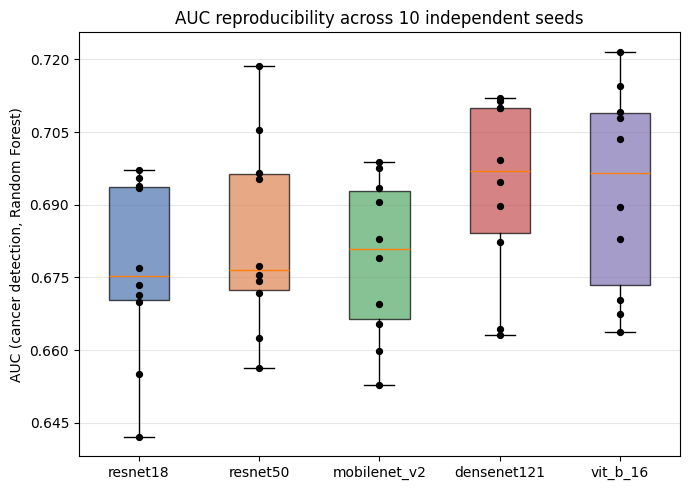

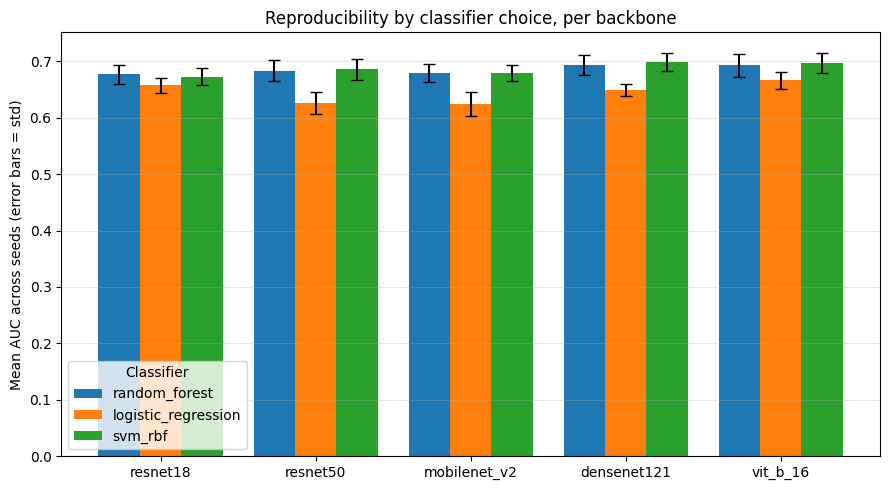

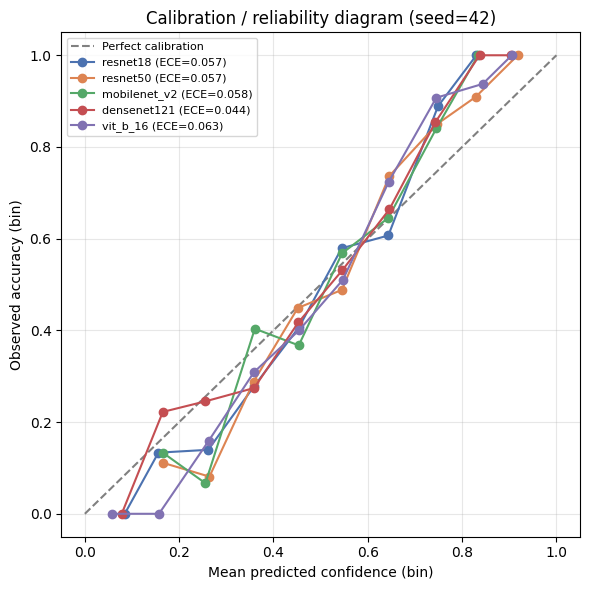

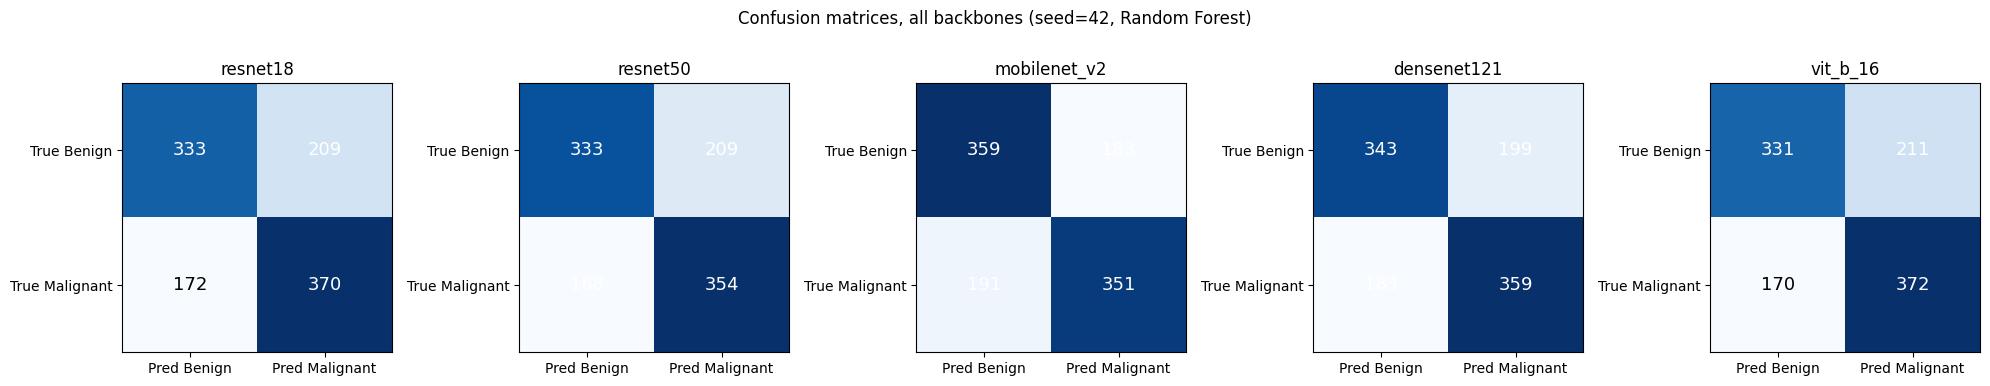

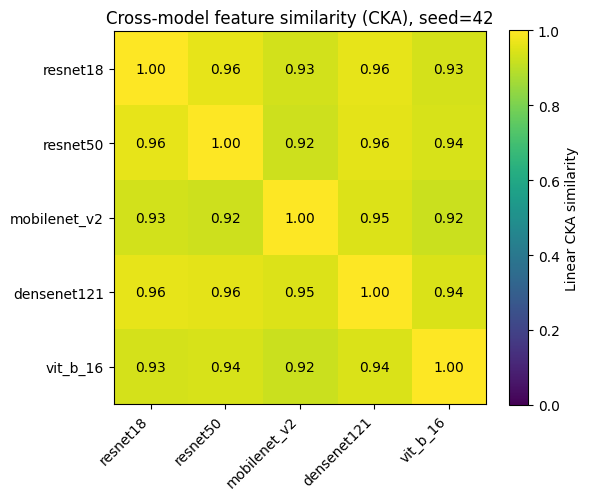

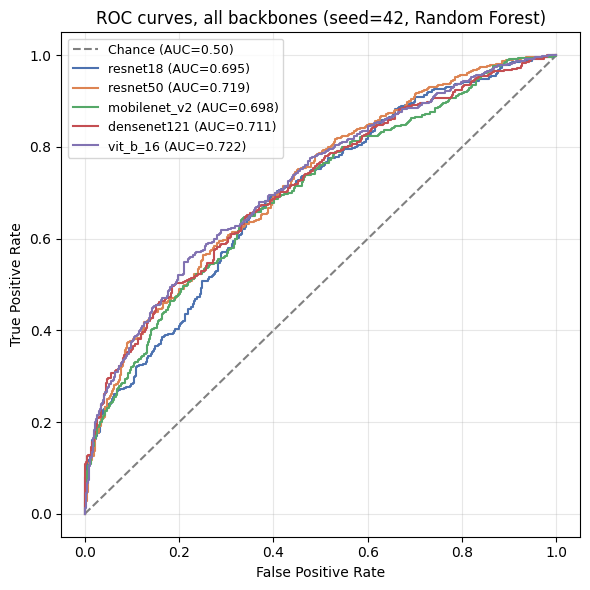

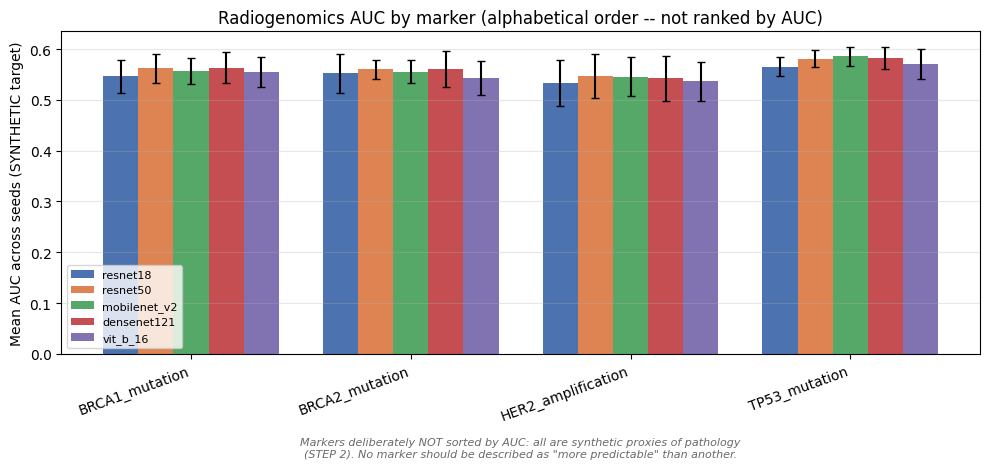


All figures saved to: D:\New folder (2)\A3 Radiogenomics Cancer Detection\Figures


In [18]:
MODEL_COLORS = {'resnet18': '#4C72B0', 'resnet50': '#DD8452',
                 'mobilenet_v2': '#55A868', 'densenet121': '#C44E52',
                 'vit_b_16': '#8172B2'}


def plot_auc_reproducibility(all_seed_results, model_names=MODEL_NAMES, save=True):
    """Box plot of AUC across seeds, one box per backbone -- the primary
    reproducibility figure (std of this distribution IS the reproducibility
    measure, per STEP main's printed summary)."""
    data = [[all_seed_results[s]['cancer_results'][m]['auc'] for s in all_seed_results]
            for m in model_names]

    fig, ax = plt.subplots(figsize=(7, 5))
    try:
        bp = ax.boxplot(data, tick_labels=model_names, patch_artist=True, widths=0.5)
    except TypeError:  # older matplotlib (<3.9) uses "labels" instead
        bp = ax.boxplot(data, labels=model_names, patch_artist=True, widths=0.5)
    for patch, m in zip(bp['boxes'], model_names):
        patch.set_facecolor(MODEL_COLORS.get(m, '#888888'))
        patch.set_alpha(0.7)
    for i, vals in enumerate(data, start=1):
        ax.scatter([i] * len(vals), vals, color='black', zorder=3, s=18)

    ax.set_ylabel("AUC (cancer detection, Random Forest)")
    ax.set_title(f"AUC reproducibility across {len(all_seed_results)} independent seeds")
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    if save:
        fig.savefig(FIGURES_DIR / "fig1_auc_reproducibility_across_seeds.png", dpi=200)
    plt.show()
    return fig


def plot_classifier_variety_auc(all_seed_results, model_names=MODEL_NAMES,
                                 classifier_names=None, save=True):
    """Grouped bar chart: mean AUC (+/- std across seeds) per model, per
    classifier. Visual counterpart of the CLASSIFIER-VARIETY REPRODUCIBILITY
    SUMMARY printed by main() -- shows whether reproducibility holds
    regardless of classifier choice (Reviewer 1 #2 / Editor #2)."""
    if classifier_names is None:
        classifier_names = CLASSIFIER_NAMES

    x = np.arange(len(model_names))
    width = 0.8 / len(classifier_names)
    fig, ax = plt.subplots(figsize=(9, 5))

    for k, clf_name in enumerate(classifier_names):
        means, stds = [], []
        for m in model_names:
            aucs = [all_seed_results[s]['classifier_variety_results'][m][clf_name]['auc']
                    for s in all_seed_results]
            means.append(np.mean(aucs))
            stds.append(np.std(aucs))
        offset = (k - (len(classifier_names) - 1) / 2) * width
        ax.bar(x + offset, means, width, yerr=stds, capsize=4, label=clf_name)

    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.set_ylabel("Mean AUC across seeds (error bars = std)")
    ax.set_title("Reproducibility by classifier choice, per backbone")
    ax.legend(title="Classifier")
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    if save:
        fig.savefig(FIGURES_DIR / "fig2_classifier_variety_auc.png", dpi=200)
    plt.show()
    return fig


def plot_calibration_curves(all_seed_results, model_names=MODEL_NAMES,
                             seed=None, n_bins=10, save=True):
    """Reliability diagram (observed accuracy vs. mean predicted confidence,
    per bin) for one representative seed -- visual counterpart of STEP 6B's
    Brier/ECE table."""
    if seed is None:
        seed = list(all_seed_results.keys())[0]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')

    for m in model_names:
        res = all_seed_results[seed]['cancer_results'][m]
        cal = calibration_assessment(res['y_true'], res['y_pred_proba'], n_bins=n_bins)
        curve = cal['reliability_curve']
        if not curve:
            continue
        conf = [pt['mean_confidence'] for pt in curve]
        acc = [pt['observed_accuracy'] for pt in curve]
        ax.plot(conf, acc, marker='o', label=f"{m} (ECE={cal['ece']:.3f})",
                color=MODEL_COLORS.get(m))

    ax.set_xlabel("Mean predicted confidence (bin)")
    ax.set_ylabel("Observed accuracy (bin)")
    ax.set_title(f"Calibration / reliability diagram (seed={seed})")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    if save:
        fig.savefig(FIGURES_DIR / "fig3_calibration_curves.png", dpi=200)
    plt.show()
    return fig


def plot_confusion_matrices(all_seed_results, model_names=MODEL_NAMES, seed=None, save=True):
    """Small-multiple confusion-matrix heatmaps, one per backbone, same seed
    (Reviewer 2: 'numerical inconsistencies... verify against figures')."""
    if seed is None:
        seed = list(all_seed_results.keys())[0]

    fig, axes = plt.subplots(1, len(model_names), figsize=(4 * len(model_names), 4))
    if len(model_names) == 1:
        axes = [axes]

    for ax, m in zip(axes, model_names):
        cm = all_seed_results[seed]['cancer_results'][m]['confusion_matrix']
        mat = np.array([[cm['TN'], cm['FP']], [cm['FN'], cm['TP']]])
        im = ax.imshow(mat, cmap='Blues')
        for i in range(2):
            for j in range(2):
                ax.text(j, i, mat[i, j], ha='center', va='center',
                        color='white' if mat[i, j] > mat.max() / 2 else 'black', fontsize=13)
        ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred Benign', 'Pred Malignant'])
        ax.set_yticks([0, 1]); ax.set_yticklabels(['True Benign', 'True Malignant'])
        ax.set_title(m)

    fig.suptitle(f"Confusion matrices, all backbones (seed={seed}, Random Forest)")
    fig.tight_layout()
    if save:
        fig.savefig(FIGURES_DIR / "fig4_confusion_matrices.png", dpi=200)
    plt.show()
    return fig


def plot_cka_heatmap(all_seed_results, model_names=MODEL_NAMES, seed=None, save=True):
    """Cross-model feature similarity (linear CKA) heatmap -- visual
    counterpart of STEP 8's feature_reproducibility_analysis output."""
    if seed is None:
        seed = list(all_seed_results.keys())[0]

    feature_sim = all_seed_results[seed]['feature_similarity']
    n = len(model_names)
    mat = np.eye(n)
    for i, m1 in enumerate(model_names):
        for j, m2 in enumerate(model_names):
            if i == j:
                continue
            key1, key2 = f"{m1}_vs_{m2}", f"{m2}_vs_{m1}"
            if key1 in feature_sim:
                mat[i, j] = feature_sim[key1]['cka']
            elif key2 in feature_sim:
                mat[i, j] = feature_sim[key2]['cka']

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(mat, cmap='viridis', vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_xticklabels(model_names, rotation=45, ha='right')
    ax.set_yticks(range(n)); ax.set_yticklabels(model_names)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha='center', va='center',
                     color='white' if mat[i, j] < 0.6 else 'black', fontsize=10)
    fig.colorbar(im, ax=ax, label="Linear CKA similarity")
    ax.set_title(f"Cross-model feature similarity (CKA), seed={seed}")
    fig.tight_layout()
    if save:
        fig.savefig(FIGURES_DIR / "fig5_cka_heatmap.png", dpi=200)
    plt.show()
    return fig


def plot_roc_curves(all_seed_results, model_names=MODEL_NAMES, seed=None, save=True):
    """ROC curves for all 4 backbones overlaid, one representative seed."""
    if seed is None:
        seed = list(all_seed_results.keys())[0]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance (AUC=0.50)')

    for m in model_names:
        res = all_seed_results[seed]['cancer_results'][m]
        fpr, tpr, _ = roc_curve(res['y_true'], res['y_pred_proba'])
        ax.plot(fpr, tpr, label=f"{m} (AUC={res['auc']:.3f})", color=MODEL_COLORS.get(m))

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC curves, all backbones (seed={seed}, Random Forest)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    if save:
        fig.savefig(FIGURES_DIR / "fig6_roc_curves.png", dpi=200)
    plt.show()
    return fig


def plot_radiogenomics_summary(all_seed_results, model_names=MODEL_NAMES,
                                targets=None, save=True):
    """Bar chart of radiogenomics AUC (mean +/- std across seeds), per model,
    per synthetic marker. Markers are kept in FIXED ALPHABETICAL ORDER and
    NEVER sorted by AUC, per the no-marker-ranking rule from STEP 10 (this
    directly protects against the 'BRCA1 more predictable' claim the client
    feedback flagged as Not Resolved)."""
    if targets is None:
        targets = ['BRCA1_mutation', 'BRCA2_mutation', 'TP53_mutation', 'HER2_amplification']
    targets = sorted(targets)  # fixed alphabetical order -- do not sort by AUC

    x = np.arange(len(targets))
    width = 0.8 / len(model_names)
    fig, ax = plt.subplots(figsize=(10, 5))

    for k, m in enumerate(model_names):
        means, stds = [], []
        for t in targets:
            aucs = [all_seed_results[s]['radiogenomics_results'][m][t]['auc']
                    for s in all_seed_results
                    if all_seed_results[s]['radiogenomics_results'][m].get(t) is not None]
            means.append(np.mean(aucs) if aucs else np.nan)
            stds.append(np.std(aucs) if aucs else 0)
        offset = (k - (len(model_names) - 1) / 2) * width
        ax.bar(x + offset, means, width, yerr=stds, capsize=3,
               label=m, color=MODEL_COLORS.get(m))

    ax.set_xticks(x)
    ax.set_xticklabels(targets, rotation=20, ha='right')
    ax.set_ylabel("Mean AUC across seeds (SYNTHETIC target)")
    ax.set_title("Radiogenomics AUC by marker (alphabetical order -- not ranked by AUC)")
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.text(0.5, -0.32,
            "Markers deliberately NOT sorted by AUC: all are synthetic proxies of pathology\n"
            "(STEP 2). No marker should be described as \"more predictable\" than another.",
            transform=ax.transAxes, ha='center', fontsize=8, style='italic', color='dimgray')
    fig.tight_layout()
    if save:
        fig.savefig(FIGURES_DIR / "fig7_radiogenomics_summary.png", dpi=200)
    plt.show()
    return fig


_fig1 = plot_auc_reproducibility(results)
_fig2 = plot_classifier_variety_auc(results)
_fig3 = plot_calibration_curves(results)
_fig4 = plot_confusion_matrices(results)
_fig5 = plot_cka_heatmap(results)
_fig6 = plot_roc_curves(results)
_fig7 = plot_radiogenomics_summary(results)

print(f"\nAll figures saved to: {FIGURES_DIR.resolve()}")


In [38]:
def load_mias_images(mias_dir, info_path, size=RESIZE_SIZE):
    mias_dir = Path(mias_dir)
    info_path = Path(info_path)
    if not mias_dir.exists() or not info_path.exists():
        # attempt alternative location
        alt = mias_dir / "Info.txt"
        if alt.exists():
            info_path = alt
        else:
            print(f"⚠️  MIAS_DIR or MIAS_INFO_PATH not found. Skipping external validation.")
            return np.array([]), np.array([]), []

    data = []
    with open(info_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) < 7:
                continue
            record = {
                'REFNUM': parts[0],
                'BG': parts[1],
                'CLASS': parts[2],
                'SEVERITY': parts[3],
                'X': parts[4],
                'Y': parts[5],
                'RADIUS': parts[6]
            }
            data.append(record)
    if not data:
        print("⚠️  No data parsed from Info.txt. Check file format.")
        return np.array([]), np.array([]), []

    info = pd.DataFrame(data)
    info = info[info['SEVERITY'].isin(['B', 'M'])].copy()
    info['label'] = (info['SEVERITY'] == 'M').astype(int)
    info = info.sort_values('label', ascending=False).drop_duplicates('REFNUM')

    images, labels, refs = [], [], []
    for _, row in info.iterrows():
        refnum = str(row['REFNUM']).strip()
        candidates = list(mias_dir.glob(f"{refnum}.*"))
        if not candidates:
            continue
        img = load_image(candidates[0], size=size)
        if img is None:
            continue
        images.append(img)
        labels.append(row['label'])
        refs.append(refnum)

    print(f"MIAS: loaded {len(images)}/{len(info)} benign-or-malignant images "
          f"({int(np.sum(labels))} malignant / {len(labels) - int(np.sum(labels))} benign).")
    return np.array(images), np.array(labels), refs

In [39]:
def run_external_validation(master, mias_dir=MIAS_DIR, mias_info_path=MIAS_INFO_PATH,
                             seed=RANDOM_SEEDS[0]):
    """Trains each backbone's Random Forest classifier on the FULL CBIS-DDSM
    training partition (same patient-level split as internal seed=RANDOM_SEEDS[0])
    and evaluates it on MIAS, a dataset never touched during any CBIS-DDSM
    split or hyperparameter decision. Returns a per-model AUC + 95% CI table,
    directly comparable to the internal test-set AUCs already in `results`."""
    print("\n" + "=" * 70)
    print("STEP 14: EXTERNAL VALIDATION ON MIAS (independent dataset)")
    print("=" * 70)

    X_mias, y_mias, ref_mias = load_mias_images(mias_dir, mias_info_path)
    if len(X_mias) == 0:
        return None

    train_df, _ = patient_level_split(master, test_size=TEST_SIZE, seed=seed)
    X_train, y_train, pid_train = load_images_from_folders(
        train_df, IMAGE_FOLDER, IMAGE_TYPE, MAX_IMAGES_PER_PATIENT, "Train(external-val)")
    if BALANCE_DATA:
        rng = np.random.default_rng(seed)
        X_train, y_train, pid_train = balance_classes(X_train, y_train, pid_train, rng)

    rows = []
    for mname in MODEL_NAMES:
        extractor = DLExtractor(mname)
        train_feat = extractor.extract_batch(X_train)
        mias_feat = extractor.extract_batch(X_mias)
        del extractor
        gc.collect()

        scaler = StandardScaler()
        train_feat_s = scaler.fit_transform(train_feat)
        mias_feat_s = scaler.transform(mias_feat)

        clf = build_classifier('random_forest', seed)
        clf.fit(train_feat_s, y_train)
        y_pred_proba = clf.predict_proba(mias_feat_s)[:, 1]
        ext_metrics = full_metrics_with_ci(y_mias, y_pred_proba, seed=seed)

        rows.append({
            'model': mname,
            'external_n': len(y_mias),
            'external_auc': ext_metrics['auc'],
            'external_auc_ci_low': ext_metrics['auc_ci'][0],
            'external_auc_ci_high': ext_metrics['auc_ci'][1],
        })
        print(f"  {mname:14s} MIAS external AUC = {ext_metrics['auc']:.4f} "
              f"(95% CI {ext_metrics['auc_ci'][0]:.4f}-{ext_metrics['auc_ci'][1]:.4f}, "
              f"n={len(y_mias)})")

    ext_df = pd.DataFrame(rows)

    # --- Compare against the internal CBIS-DDSM test AUC (same seed) -------
    internal_aucs = {m: results[seed]['cancer_results'][m]['auc'] for m in MODEL_NAMES}
    ext_df['internal_test_auc'] = ext_df['model'].map(internal_aucs)
    ext_df['auc_drop_internal_minus_external'] = ext_df['internal_test_auc'] - ext_df['external_auc']

    print("\nInternal (CBIS-DDSM) vs. external (MIAS) AUC comparison:")
    print(ext_df.to_string(index=False))
    print("\nNote for the manuscript: with only ~n=" + str(int(ext_df['external_n'].iloc[0])) +
          " external images, these external CIs are necessarily wide -- report them "
          "as a preliminary/limited-sample generalizability check, not as a large-scale "
          "external-validation study, and recommend a larger external cohort as future work.")

    return ext_df



master = build_master_folder_list(METADATA_CSV, CALC_CSV, MASS_CSV)


if 'results' not in globals():
    import json as _json
    _seed0 = RANDOM_SEEDS[0]
    try:
        with open('reproducibility_artifacts.json') as _f:
            _manifest = _json.load(_f)
        results = {
            _seed0: {
                'cancer_results': {
                    m: {'auc': _manifest['cancer_detection_summary'][m]['auc_per_seed'][str(_seed0)]}
                    for m in MODEL_NAMES
                }
            }
        }
        print(f"`results` not in memory -- reloaded internal AUC (seed={_seed0}) from "
              "reproducibility_artifacts.json instead of re-running main().")
    except FileNotFoundError:
        raise RuntimeError(
            "`results` is not in memory and reproducibility_artifacts.json was not "
            "found in the current working directory. Either re-run main() above, "
            "or make sure Jupyter's working directory is the folder that file is in."
        )

external_validation_df = run_external_validation(master)

STEP 1: BUILDING MASTER LABELED FOLDER LIST
Metadata folders: 6775
Unique patients: 1566
Calc records: 1872, Mass records: 1696

Pathology:
pathology
MALIGNANT                  1457
BENIGN                     1429
BENIGN_WITHOUT_CALLBACK     682
Name: count, dtype: int64

Patients: 1566 (Benign=814, Malignant=752)

Dataset construction log:
  Metadata rows (start):                6775
  After inner-join with pathology table: 6775  (0 dropped: no pathology match)
  After dropping missing labels:         6775  (0 dropped: missing label)

Master records: 6775
Series Description:
series_description
ROI mask images          3565
full mammogram images    3103
cropped images            107
Name: count, dtype: int64
Label distribution: {0: 3698, 1: 3077}

STEP 14: EXTERNAL VALIDATION ON MIAS (independent dataset)
MIAS: loaded 111/112 benign-or-malignant images (49 malignant / 62 benign).

STEP 3: PATIENT-LEVEL TRAIN/TEST SPLIT
Total patients: 1566 | seed = 42
Train patients: 1253 | Test patien

Train(external-val): 100%|█████████████████████████████████████████████████████████| 2833/2833 [04:16<00:00, 11.05it/s]


  Loading resnet18 (dim=512)...


  resnet18       MIAS external AUC = 0.5174 (95% CI 0.4159-0.6283, n=111)
  Loading resnet50 (dim=2048)...


  resnet50       MIAS external AUC = 0.4717 (95% CI 0.3648-0.5826, n=111)
  Loading mobilenet_v2 (dim=1280)...


  mobilenet_v2   MIAS external AUC = 0.4891 (95% CI 0.3793-0.6046, n=111)
  Loading densenet121 (dim=1024)...


  densenet121    MIAS external AUC = 0.3683 (95% CI 0.2695-0.4764, n=111)
  Loading vit_b_16 (dim=768)...


  vit_b_16       MIAS external AUC = 0.5056 (95% CI 0.3963-0.6109, n=111)

Internal (CBIS-DDSM) vs. external (MIAS) AUC comparison:
       model  external_n  external_auc  external_auc_ci_low  external_auc_ci_high  internal_test_auc  auc_drop_internal_minus_external
    resnet18         111      0.517446             0.415879              0.628317           0.695473                          0.178028
    resnet50         111      0.471692             0.364833              0.582621           0.718679                          0.246987
mobilenet_v2         111      0.489138             0.379312              0.604575           0.697676                          0.208538
 densenet121         111      0.368334             0.269501              0.476399           0.711452                          0.343118
    vit_b_16         111      0.505596             0.396321              0.610944           0.721630                          0.216035

Note for the manuscript: with only ~n=111 external images

### STEP 14B — Visualization: internal vs. external AUC
Bar chart comparing each backbone's CBIS-DDSM (internal) test AUC against
its MIAS (external) AUC, with 95% CI error bars on the external estimate.

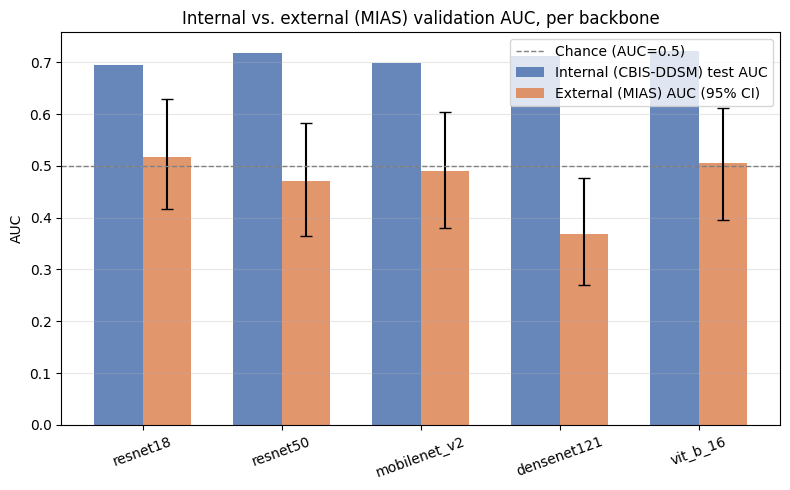

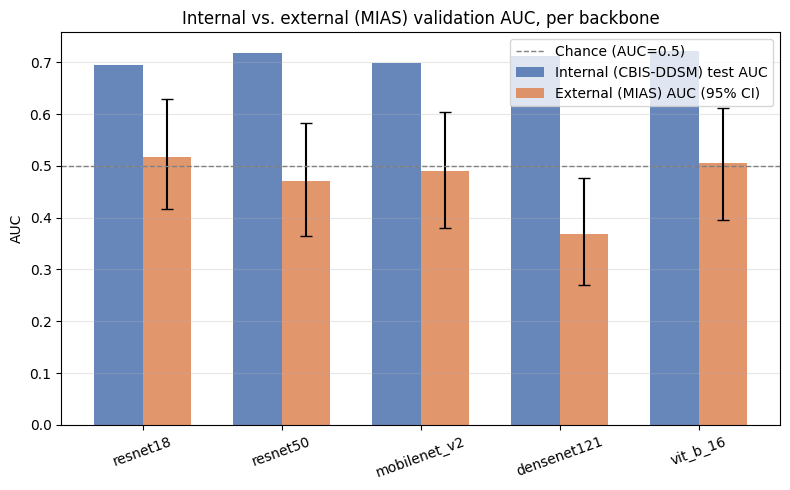

In [44]:
def plot_external_validation(external_validation_df, save=True):
    if external_validation_df is None or len(external_validation_df) == 0:
        print("No external validation results to plot (MIAS not found -- see STEP 14).")
        return None

    df = external_validation_df
    x = np.arange(len(df))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width/2, df['internal_test_auc'], width, label='Internal (CBIS-DDSM) test AUC',
           color='#4C72B0', alpha=0.85)
    yerr = np.array([df['external_auc'] - df['external_auc_ci_low'],
                      df['external_auc_ci_high'] - df['external_auc']])
    ax.bar(x + width/2, df['external_auc'], width, yerr=yerr, capsize=4,
           label='External (MIAS) AUC (95% CI)', color='#DD8452', alpha=0.85)

    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Chance (AUC=0.5)')
    ax.set_xticks(x)
    ax.set_xticklabels(df['model'], rotation=20)
    ax.set_ylabel("AUC")
    ax.set_title("Internal vs. external (MIAS) validation AUC, per backbone")
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    if save:
        fig.savefig(FIGURES_DIR / "fig8_internal_vs_external_auc.png", dpi=200)
    plt.show()
    return fig


plot_external_validation(external_validation_df)

In [43]:


from sklearn.model_selection import GridSearchCV, StratifiedKFold

NESTED_CV_SEED = RANDOM_SEEDS[0]
NESTED_CV_INNER_FOLDS = 5

PARAM_GRIDS = {
    'random_forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [8, 12, 16, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
    },
    'logistic_regression': {
        'C': [0.01, 0.1, 1.0, 10.0],
        'penalty': ['l2'],
        'solver': ['lbfgs'],
    },
    'svm_rbf': {
        'C': [0.1, 1.0, 10.0],
        'gamma': ['scale', 'auto', 0.01, 0.1],
    },
}


def base_estimator(classifier_name, seed):
    """Unfitted base estimator for GridSearchCV -- same model families as
    build_classifier() in STEP 6, but WITHOUT the fixed hyperparameters,
    since those are exactly what the inner grid search will select."""
    if classifier_name == 'random_forest':
        return RandomForestClassifier(random_state=seed, class_weight='balanced',
                                       bootstrap=True, n_jobs=-1)
    elif classifier_name == 'logistic_regression':
        return LogisticRegression(random_state=seed, class_weight='balanced', max_iter=2000)
    elif classifier_name == 'svm_rbf':
        return SVC(random_state=seed, class_weight='balanced', probability=True)
    else:
        raise ValueError(f"Unknown classifier_name: {classifier_name}")


def nested_cv_train_and_eval(X_train, y_train, X_test, y_test, seed, classifier_name):
    """Inner loop: StratifiedKFold grid search on the TRAINING set only (the
    test set is never touched during tuning -- no leakage). Outer
    evaluation: refit the best model on the full training set, then
    evaluate once on the held-out test set, exactly like the
    fixed-hyperparameter pipeline in STEP 6, so the two are directly
    comparable."""
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    inner_cv = StratifiedKFold(n_splits=NESTED_CV_INNER_FOLDS, shuffle=True, random_state=seed)
    search = GridSearchCV(
        estimator=base_estimator(classifier_name, seed),
        param_grid=PARAM_GRIDS[classifier_name],
        scoring='roc_auc',
        cv=inner_cv,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train_s, y_train)

    y_pred_proba = search.best_estimator_.predict_proba(X_test_s)[:, 1]
    metrics = full_metrics_with_ci(y_test, y_pred_proba, seed=seed)
    metrics['classifier'] = classifier_name
    metrics['best_params'] = search.best_params_
    metrics['inner_cv_best_score'] = search.best_score_
    return metrics


print("=" * 70)
print("STEP 6C: NESTED CROSS-VALIDATION vs. FIXED HYPERPARAMETERS")
print(f"  (single-seed check, seed={NESTED_CV_SEED}, {NESTED_CV_INNER_FOLDS}-fold inner CV)")
print("=" * 70)

master = build_master_folder_list(METADATA_CSV, CALC_CSV, MASS_CSV)
train_df, test_df = patient_level_split(master, test_size=TEST_SIZE, seed=NESTED_CV_SEED)

X_train, y_train, pid_train = load_images_from_folders(
    train_df, IMAGE_FOLDER, IMAGE_TYPE, MAX_IMAGES_PER_PATIENT, "Train(nested-CV)")
X_test, y_test, pid_test = load_images_from_folders(
    test_df, IMAGE_FOLDER, IMAGE_TYPE, MAX_IMAGES_PER_PATIENT, "Test(nested-CV)")

rng = np.random.default_rng(NESTED_CV_SEED)
if BALANCE_DATA:
    X_train, y_train, pid_train = balance_classes(X_train, y_train, pid_train, rng)
    X_test, y_test, pid_test = balance_classes(X_test, y_test, pid_test, rng)

nested_cv_rows = []
for mname in MODEL_NAMES:
    print(f"\n  Extracting features for {mname}...")
    extractor = DLExtractor(mname)
    train_feat = extractor.extract_batch(X_train)
    test_feat = extractor.extract_batch(X_test)
    del extractor
    gc.collect()

    for clf_name in CLASSIFIER_NAMES:
        print(f"    Nested CV: {mname} + {clf_name} ...")
        tuned = nested_cv_train_and_eval(train_feat, y_train, test_feat, y_test,
                                          seed=NESTED_CV_SEED, classifier_name=clf_name)
        fixed = train_and_eval_cancer_classifier(train_feat, y_train, test_feat, y_test,
                                                  seed=NESTED_CV_SEED, classifier_name=clf_name)

        nested_cv_rows.append({
            'model': mname,
            'classifier': clf_name,
            'fixed_hp_auc': fixed['auc'],
            'fixed_hp_auc_ci': fixed['auc_ci'],
            'nested_cv_auc': tuned['auc'],
            'nested_cv_auc_ci': tuned['auc_ci'],
            'auc_diff': tuned['auc'] - fixed['auc'],
            'ci_overlap': not (tuned['auc_ci'][0] > fixed['auc_ci'][1]
                                or fixed['auc_ci'][0] > tuned['auc_ci'][1]),
            'best_params': tuned['best_params'],
            'inner_cv_best_score': tuned['inner_cv_best_score'],
        })

nested_cv_df = pd.DataFrame(nested_cv_rows)
print(f"\nNested-CV vs. fixed-hyperparameter AUC comparison (seed={NESTED_CV_SEED}):")
print(nested_cv_df[['model', 'classifier', 'fixed_hp_auc', 'nested_cv_auc',
                     'auc_diff', 'ci_overlap']].to_string(index=False))

n_overlap = int(nested_cv_df['ci_overlap'].sum())
n_total = len(nested_cv_df)
verdict = "supports" if n_overlap == n_total else "partially supports"
print(f"\n{n_overlap}/{n_total} model-classifier combinations have overlapping 95% CIs between "
      f"fixed-hyperparameter and nested-CV-tuned AUC -- this {verdict} the conclusion that "
      "fixed hyperparameters were not a major driver of the reported reproducibility pattern.")

print("\nLIMITATION (state explicitly in manuscript): this comparison uses a single "
      f"representative seed ({NESTED_CV_SEED}), not the full N_SEEDS={N_SEEDS}-seed protocol, "
      "due to the compute cost of an inner-loop search x 10 seeds x 5 backbones x 3 "
      "classifiers. A full multi-seed nested-CV replication is recommended as future work "
      "before deployment-oriented claims.")

nested_cv_df.to_csv("nested_cv_vs_fixed_hyperparameters.csv", index=False)

STEP 6C: NESTED CROSS-VALIDATION vs. FIXED HYPERPARAMETERS
  (single-seed check, seed=42, 5-fold inner CV)
STEP 1: BUILDING MASTER LABELED FOLDER LIST
Metadata folders: 6775
Unique patients: 1566
Calc records: 1872, Mass records: 1696

Pathology:
pathology
MALIGNANT                  1457
BENIGN                     1429
BENIGN_WITHOUT_CALLBACK     682
Name: count, dtype: int64

Patients: 1566 (Benign=814, Malignant=752)

Dataset construction log:
  Metadata rows (start):                6775
  After inner-join with pathology table: 6775  (0 dropped: no pathology match)
  After dropping missing labels:         6775  (0 dropped: missing label)

Master records: 6775
Series Description:
series_description
ROI mask images          3565
full mammogram images    3103
cropped images            107
Name: count, dtype: int64
Label distribution: {0: 3698, 1: 3077}

STEP 3: PATIENT-LEVEL TRAIN/TEST SPLIT
Total patients: 1566 | seed = 42
Train patients: 1253 | Test patients: 313
Train folders: 5402 |

Train(nested-CV): 100%|████████████████████████████████████████████████████████████| 2833/2833 [03:21<00:00, 14.09it/s]


  Filtered to 'ROI mask images': 732 folders


Test(nested-CV): 100%|███████████████████████████████████████████████████████████████| 732/732 [01:02<00:00, 11.81it/s]



  Extracting features for resnet18...
  Loading resnet18 (dim=512)...


    Nested CV: resnet18 + random_forest ...
    Nested CV: resnet18 + logistic_regression ...
    Nested CV: resnet18 + svm_rbf ...

  Extracting features for resnet50...
  Loading resnet50 (dim=2048)...


    Nested CV: resnet50 + random_forest ...
    Nested CV: resnet50 + logistic_regression ...
    Nested CV: resnet50 + svm_rbf ...

  Extracting features for mobilenet_v2...
  Loading mobilenet_v2 (dim=1280)...


    Nested CV: mobilenet_v2 + random_forest ...
    Nested CV: mobilenet_v2 + logistic_regression ...
    Nested CV: mobilenet_v2 + svm_rbf ...

  Extracting features for densenet121...
  Loading densenet121 (dim=1024)...


    Nested CV: densenet121 + random_forest ...
    Nested CV: densenet121 + logistic_regression ...
    Nested CV: densenet121 + svm_rbf ...

  Extracting features for vit_b_16...
  Loading vit_b_16 (dim=768)...


    Nested CV: vit_b_16 + random_forest ...
    Nested CV: vit_b_16 + logistic_regression ...
    Nested CV: vit_b_16 + svm_rbf ...

Nested-CV vs. fixed-hyperparameter AUC comparison (seed=42):
       model          classifier  fixed_hp_auc  nested_cv_auc  auc_diff  ci_overlap
    resnet18       random_forest      0.695473       0.688594 -0.006880        True
    resnet18 logistic_regression      0.666161       0.693989  0.027828        True
    resnet18             svm_rbf      0.684762       0.684755 -0.000007        True
    resnet50       random_forest      0.718679       0.713535 -0.005144        True
    resnet50 logistic_regression      0.655996       0.704542  0.048546        True
    resnet50             svm_rbf      0.715195       0.715195  0.000000        True
mobilenet_v2       random_forest      0.697676       0.706911  0.009235        True
mobilenet_v2 logistic_regression      0.650972       0.697825  0.046854        True
mobilenet_v2             svm_rbf      0.695591    

✅ Figure saved to: figures\fig_supp_nested_cv_comparison.png


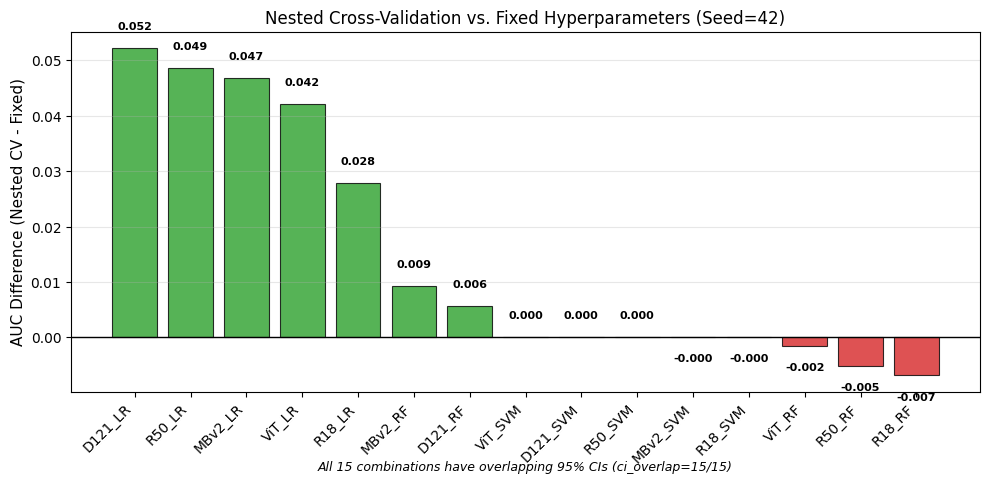

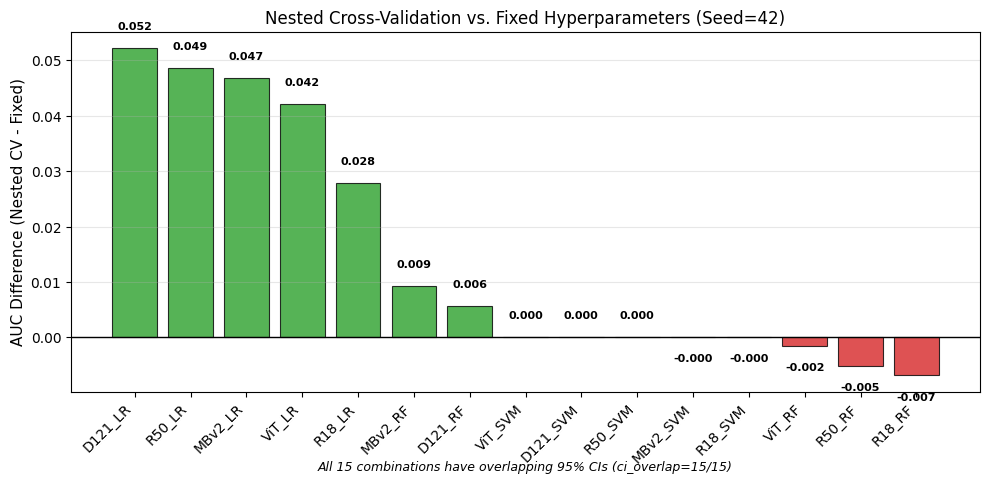

In [46]:
def plot_nested_cv_clean(nested_cv_df, save=True):
    """
    Clean publication-ready plot for Nested CV vs Fixed hyperparameters.
    Uses short labels to avoid overlap.
    """
    if nested_cv_df is None or len(nested_cv_df) == 0:
        print("No nested CV data found.")
        return None

    df = nested_cv_df.copy()
    
    # Create short labels: e.g., "R18_RF", "R18_LR", "R18_SVM"
    model_short = {
        'resnet18': 'R18',
        'resnet50': 'R50',
        'mobilenet_v2': 'MBv2',
        'densenet121': 'D121',
        'vit_b_16': 'ViT'
    }
    clf_short = {
        'random_forest': 'RF',
        'logistic_regression': 'LR',
        'svm_rbf': 'SVM'
    }
    df['short_label'] = df.apply(
        lambda row: f"{model_short.get(row['model'], row['model'])}_"
                    f"{clf_short.get(row['classifier'], row['classifier'])}",
        axis=1
    )
    
    # Sort by difference (descending)
    df = df.sort_values('auc_diff', ascending=False).reset_index(drop=True)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(df))
    diffs = df['auc_diff'].values
    
    # Colors: Green if diff > 0 (tuned better), Red if diff < 0 (fixed better)
    colors = ['#2ca02c' if d > 0 else '#d62728' for d in diffs]
    
    bars = ax.bar(x, diffs, color=colors, alpha=0.8, edgecolor='black', linewidth=0.8)
    
    # Horizontal line at zero
    ax.axhline(0, color='black', linestyle='-', linewidth=1)
    
    # Labels and title
    ax.set_xticks(x)
    ax.set_xticklabels(df['short_label'], rotation=45, ha='right', fontsize=10)
    ax.set_ylabel("AUC Difference (Nested CV - Fixed)", fontsize=11)
    ax.set_title("Nested Cross-Validation vs. Fixed Hyperparameters (Seed=42)", fontsize=12)
    
    # Add value labels on bars
    for bar, diff in zip(bars, diffs):
        height = bar.get_height()
        va = 'bottom' if height >= 0 else 'top'
        offset = 0.003 if height >= 0 else -0.003
        ax.text(bar.get_x() + bar.get_width()/2., height + offset,
                f'{diff:.3f}', ha='center', va=va, fontsize=8, fontweight='bold')
    
    # Add a note about CI overlap
    n_overlap = df['ci_overlap'].sum()
    ax.text(0.5, -0.22, 
            f"All {len(df)} combinations have overlapping 95% CIs (ci_overlap={n_overlap}/{len(df)})",
            transform=ax.transAxes, ha='center', fontsize=9, style='italic')
    
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    
    if save:
        fig.savefig(FIGURES_DIR / "fig_supp_nested_cv_comparison.png", dpi=300, bbox_inches='tight')
        print(f"✅ Figure saved to: {FIGURES_DIR / 'fig_supp_nested_cv_comparison.png'}")
    
    plt.show()
    return fig

# Run the plot
plot_nested_cv_clean(nested_cv_df)